# ☕ Capstone Data Analysis: Coffee Shop Sales
## Tahap 5: Exploratory Data Analysis

---

# 1. Objective

Tujuan dari Exploratory Data Analysis (EDA) ini adalah:

- **Memahami pola penjualan** secara keseluruhan dari data transaksi coffee shop
- **Menemukan produk dan kategori terbaik maupun terburuk** berdasarkan revenue, quantity, dan frekuensi transaksi
- **Memahami perilaku pelanggan** melalui segmentasi, frekuensi, dan nilai transaksi
- **Membandingkan performa cabang atau wilayah** untuk mengidentifikasi lokasi dengan performa terbaik dan terendah
- **Menemukan pola waktu penjualan** (bulanan, harian, jam) untuk optimasi operasional
- **Menganalisis revenue, diskon, dan dampaknya** terhadap performa bisnis
- **Menghasilkan insight** sebagai dasar pembuatan dashboard dan rekomendasi bisnis

**Dataset:** `processed/coffee_shop_sales_featured.csv`

---

# 2. Business Questions

Notebook ini menjawab pertanyaan-pertanyaan bisnis berikut:

## 2.1 Sales
- Bagaimana tren penjualan dari waktu ke waktu?
- Kapan penjualan tertinggi dan terendah?
- Produk atau kategori apa yang paling berkontribusi terhadap penjualan?
- Bagaimana perubahan jumlah transaksi dan quantity dari waktu ke waktu?
- Apakah revenue meningkat, menurun, atau stabil?

## 2.2 Product
- Produk apa yang paling laris berdasarkan quantity?
- Produk apa yang menghasilkan revenue terbesar?
- Produk atau kategori apa yang memiliki performa terendah?
- Produk mana yang paling sering mendapatkan diskon?
- Produk mana yang layak diprioritaskan atau dievaluasi?

## 2.3 Customer
- Siapa pelanggan dengan total belanja terbesar?
- Siapa pelanggan dengan frekuensi transaksi tertinggi?
- Bagaimana distribusi pelanggan berdasarkan age group?
- Bagaimana perilaku pembelian berdasarkan gender?
- Apakah terdapat segmen pelanggan yang berbeda?
- Bagaimana perbedaan average transaction value antar segmen?

## 2.4 Region
- Negara atau kota mana yang memiliki revenue tertinggi?
- Cabang atau store mana yang memiliki performa terbaik?
- Cabang mana yang memiliki performa terendah?
- Apakah terdapat perbedaan pola penjualan antar store type?
- Wilayah mana yang perlu diprioritaskan untuk investasi atau perbaikan?

## 2.5 Time
- Bulan apa yang memiliki penjualan tertinggi dan terendah?
- Hari apa yang paling ramai?
- Jam berapa transaksi paling tinggi?
- Bagaimana perbedaan weekday dan weekend?
- Apakah terdapat pola musiman?
- Kapan waktu terbaik untuk promosi dan penambahan staf?

## 2.6 Profit atau Sales Performance
- Dataset tidak menyediakan kolom cost, profit, atau margin
- Analisis difokuskan pada revenue, transaction volume, quantity, dan discount behavior

---

In [1]:
# ============================================================
# Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Konfigurasi
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Konfigurasi matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Konfigurasi seaborn
sns.set_palette('husl')
sns.set_style('whitegrid')

print('Library berhasil diimport.')

Library berhasil diimport.


---
# 3. Load Featured Dataset

Memuat dataset hasil Feature Engineering dari tahap sebelumnya.

In [2]:
# ============================================================
# Load Featured Dataset
# ============================================================
FILE_PATH = 'processed/coffee_shop_sales_featured.csv'

# Cek apakah file tersedia
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f'File tidak ditemukan: {FILE_PATH}')

df = pd.read_csv(FILE_PATH)

# Pastikan kolom timestamp tetap bertipe datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
print('Timestamp dikonversi ke datetime.')

print('=' * 70)
print(' FEATURED DATASET LOADED')
print('=' * 70)
print(f'\nFile: {FILE_PATH}')
print(f'Shape: {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'\nDaftar Kolom:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col} ({df[col].dtype})')

Timestamp dikonversi ke datetime.
 FEATURED DATASET LOADED

File: processed/coffee_shop_sales_featured.csv
Shape: 20,000 baris x 37 kolom

Daftar Kolom:
   1. transaction_id (int64)
   2. timestamp (datetime64[us])
   3. store_id (int64)
   4. city (str)
   5. country (str)
   6. store_type (str)
   7. product_category (str)
   8. product_name (str)
   9. unit_price (float64)
  10. quantity (int64)
  11. discount_applied (bool)
  12. payment_method (str)
  13. customer_id (str)
  14. customer_age_group (str)
  15. customer_gender (str)
  16. loyalty_member (bool)
  17. weather_condition (str)
  18. temperature_c (float64)
  19. holiday_name (str)
  20. total_amount (float64)
  21. is_holiday (bool)
  22. month (int64)
  23. month_name (str)
  24. quarter (int64)
  25. quarter_label (str)
  26. day_of_week (int64)
  27. day_name (str)
  28. hour (int64)
  29. time_period (str)
  30. is_weekend (bool)
  31. price_category (str)
  32. basket_size (str)
  33. total_spending (float64)
  34.

In [3]:
# ============================================================
# Tampilkan Lima Baris Pertama
# ============================================================
df.head(10)

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount,is_holiday,month,month_name,quarter,quarter_label,day_of_week,day_name,hour,time_period,is_weekend,price_category,basket_size,total_spending,customer_segment,discount_amount,discount_impact,revenue_category
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,True,Sunny,22.20,New Year's Day,2.74,True,1,January,1,Q1 (Jan-Mar),6,Sunday,0,Night (22-6),True,Medium Price,Small (1),2.74,Low Value,0.30,Low Discount (<= $2),Low Revenue
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,True,Debit Card,vf0jqqnv,18-24,Male,True,Sunny,8.70,New Year's Day,4.76,True,1,January,1,Q1 (Jan-Mar),6,Sunday,1,Night (22-6),True,Low Price,Medium (2-3),4.76,Medium Value,0.00,No Discount,Medium Revenue
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,True,Mobile Wallet,fcd6mzsg,25-34,Male,True,Sunny,8.70,New Year's Day,8.52,True,1,January,1,Q1 (Jan-Mar),6,Sunday,2,Night (22-6),True,Medium Price,Medium (2-3),8.52,High Value,0.00,No Discount,Premium Revenue
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,True,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.50,New Year's Day,7.36,True,1,January,1,Q1 (Jan-Mar),6,Sunday,2,Night (22-6),True,Medium Price,Medium (2-3),7.36,High Value,0.00,No Discount,High Revenue
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,True,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.30,New Year's Day,3.42,True,1,January,1,Q1 (Jan-Mar),6,Sunday,3,Night (22-6),True,Medium Price,Small (1),7.70,High Value,0.00,No Discount,Medium Revenue
5,10006,2023-01-01 03:23:03,42,Vancouver,CAN,Standalone,Tea,Large Green Tea,3.01,1,True,Cash,2eclces1,25-34,Female,True,Sunny,2.80,New Year's Day,3.01,True,1,January,1,Q1 (Jan-Mar),6,Sunday,3,Night (22-6),True,Medium Price,Small (1),3.01,Low Value,0.00,No Discount,Low Revenue
6,10007,2023-01-01 03:42:51,12,Chicago,USA,Airport,Tea,Medium Earl Grey,3.32,1,True,Cash,4es3aofc,65+,Male,True,Sunny,-4.70,New Year's Day,3.32,True,1,January,1,Q1 (Jan-Mar),6,Sunday,3,Night (22-6),True,Medium Price,Small (1),9.43,High Value,0.00,No Discount,Low Revenue
7,10008,2023-01-01 04:04:29,21,Manchester,UK,Standalone,Coffee,Large Cappuccino,3.77,2,True,Credit Card,c8nog85d,55-64,Unknown,True,Sunny,8.70,New Year's Day,7.54,True,1,January,1,Q1 (Jan-Mar),6,Sunday,4,Night (22-6),True,Medium Price,Medium (2-3),7.54,High Value,0.00,No Discount,High Revenue
8,10009,2023-01-01 04:26:29,27,Sydney,AUS,Standalone,Tea,Large Matcha Latte,5.72,1,True,Credit Card,pceo934t,Unknown,Female,True,Cloudy,16.60,New Year's Day,5.72,True,1,January,1,Q1 (Jan-Mar),6,Sunday,4,Night (22-6),True,Premium,Small (1),5.72,Medium Value,0.00,No Discount,High Revenue
9,10010,2023-01-01 05:41:05,7,Los Angeles,USA,Standalone,Coffee,Large Cappuccino,4.51,2,True,Cash,idbx287g,35-44,Female,True,Sunny,12.30,New Year's Day,9.02,True,1,January,1,Q1 (Jan-Mar),6,Sunday,5,Night (22-6),True,Medium Price,Medium (2-3),9.02,High Value,0.00,No Discount,Premium Revenue


In [4]:
# ============================================================
# Info Dataset
# ============================================================
print('=' * 70)
print(' INFORMASI DATASET')
print('=' * 70)
df.info()

print(f'\nMissing Values: {df.isnull().sum().sum():,}')
print(f'Duplicate Rows: {df.duplicated().sum():,}')
print(f'Rentang Tanggal: {df["timestamp"].min()} s/d {df["timestamp"].max()}')
print(f'Jumlah Transaksi Unik: {df["transaction_id"].nunique():,}')
print(f'Jumlah Pelanggan Unik: {df["customer_id"].nunique():,}')
print(f'Jumlah Store Unik: {df["store_id"].nunique():,}')
print(f'Jumlah Produk Unik: {df["product_name"].nunique():,}')

 INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      20000 non-null  int64         
 1   timestamp           20000 non-null  datetime64[us]
 2   store_id            20000 non-null  int64         
 3   city                20000 non-null  str           
 4   country             20000 non-null  str           
 5   store_type          20000 non-null  str           
 6   product_category    20000 non-null  str           
 7   product_name        20000 non-null  str           
 8   unit_price          20000 non-null  float64       
 9   quantity            20000 non-null  int64         
 10  discount_applied    20000 non-null  bool          
 11  payment_method      20000 non-null  str           
 12  customer_id         20000 non-null  str           
 13  customer_age_group  20000 non-null  st

---
# 4. EDA Preparation

Persiapan sebelum analisis eksplorasi.

In [5]:
# ============================================================
# EDA Preparation
# ============================================================

# Buat salinan DataFrame
df_eda = df.copy()
df_eda['timestamp'] = pd.to_datetime(df_eda['timestamp'])

# Identifikasi kolom numerik
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom Numerik ({len(numeric_cols)}): {numeric_cols}')

# Identifikasi kolom kategorikal
categorical_cols = df_eda.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Kolom Kategorikal ({len(categorical_cols)}): {categorical_cols}')

# Identifikasi kolom datetime
datetime_cols = df_eda.select_dtypes(include=['datetime64']).columns.tolist()
print(f'Kolom DateTime ({len(datetime_cols)}): {datetime_cols}')

# Identifikasi kolom boolean
bool_cols = df_eda.select_dtypes(include=['bool']).columns.tolist()
print(f'Kolom Boolean ({len(bool_cols)}): {bool_cols}')

# Cek duplikasi baru
print(f'\nDuplicate Rows: {df_eda.duplicated().sum():,}')

# Cek missing value
missing = df_eda.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(f'\nKolom dengan Missing Values:')
    for col, count in missing_cols.items():
        print(f'  {col}: {count:,} ({count/len(df_eda)*100:.2f}%)')
else:
    print(f'\nTIDAK ADA MISSING VALUE')

Kolom Numerik (12): ['transaction_id', 'store_id', 'unit_price', 'quantity', 'temperature_c', 'total_amount', 'month', 'quarter', 'day_of_week', 'hour', 'total_spending', 'discount_amount']
Kolom Kategorikal (20): ['city', 'country', 'store_type', 'product_category', 'product_name', 'payment_method', 'customer_id', 'customer_age_group', 'customer_gender', 'weather_condition', 'holiday_name', 'month_name', 'quarter_label', 'day_name', 'time_period', 'price_category', 'basket_size', 'customer_segment', 'discount_impact', 'revenue_category']
Kolom DateTime (1): ['timestamp']
Kolom Boolean (4): ['discount_applied', 'loyalty_member', 'is_holiday', 'is_weekend']

Duplicate Rows: 0

Kolom dengan Missing Values:
  temperature_c: 978 (4.89%)
  holiday_name: 19,665 (98.32%)


In [6]:
# ============================================================
# Ringkasan KPI Awal
# ============================================================

print('=' * 70)
print(' RINGKASAN KPI AWAL')
print('=' * 70)

# Hitung KPI
total_revenue = df_eda['total_amount'].sum()
total_transactions = len(df_eda)
total_quantity = df_eda['quantity'].sum()
avg_transaction_value = df_eda['total_amount'].mean()
avg_quantity_per_transaction = df_eda['quantity'].mean()
n_customers = df_eda['customer_id'].nunique()
n_stores = df_eda['store_id'].nunique()
n_products = df_eda['product_name'].nunique()

print(f'\n{"Metric":<40} {"Value":>20}')
print('-' * 62)
print(f'{"Total Revenue":<40} {"$" + f"{total_revenue:,.2f}":>20}')
print(f'{"Total Transaksi":<40} {f"{total_transactions:,}":>20}')
print(f'{"Total Quantity":<40} {f"{total_quantity:,}":>20}')
print(f'{"Average Transaction Value":<40} {"$" + f"{avg_transaction_value:,.2f}":>20}')
print(f'{"Avg Quantity per Transaction":<40} {f"{avg_quantity_per_transaction:.2f}":>20}')
print(f'{"Jumlah Pelanggan":<40} {f"{n_customers:,}":>20}')
print(f'{"Jumlah Store":<40} {f"{n_stores:,}":>20}')
print(f'{"Jumlah Produk":<40} {f"{n_products:,}":>20}')

 RINGKASAN KPI AWAL

Metric                                                  Value
--------------------------------------------------------------
Total Revenue                                     $137,009.27
Total Transaksi                                        20,000
Total Quantity                                         34,253
Average Transaction Value                               $6.85
Avg Quantity per Transaction                             1.71
Jumlah Pelanggan                                       19,250
Jumlah Store                                               45
Jumlah Produk                                              43


---
# 5. Sales Analysis

Analisis menyeluruh terhadap performa penjualan.

## 5.1 Overall Sales Performance

In [7]:
# ============================================================
# 5.1 Overall Sales Performance
# ============================================================

print('=' * 70)
print(' 5.1 OVERALL SALES PERFORMANCE')
print('=' * 70)

total_revenue = df_eda['total_amount'].sum()
total_txn = len(df_eda)
total_qty = df_eda['quantity'].sum()
avg_txn = df_eda['total_amount'].mean()
median_txn = df_eda['total_amount'].median()

print(f'\n{"Metric":<35} {"Value":>15}')
print('-' * 52)
print(f'{"Total Revenue":<35} {"$" + f"{total_revenue:,.2f}":>15}')
print(f'{"Total Transaction":<35} {f"{total_txn:,}":>15}')
print(f'{"Total Quantity":<35} {f"{total_qty:,}":>15}')
print(f'{"Average Transaction Value":<35} {"$" + f"{avg_txn:,.2f}":>15}')
print(f'{"Median Transaction Value":<35} {"$" + f"{median_txn:,.2f}":>15}')

print(f'\nInterpretasi:')
print(f'- Rata-rata transaksi bernilai ${avg_txn:,.2f}, lebih tinggi dari median ${median_txn:,.2f}')
print(f'  yang mengindikasikan distribusi right-skewed dengan beberapa transaksi bernilai tinggi.')
print(f'- Total revenue ${total_revenue:,.2f} dari {total_txn:,} transaksi.')

 5.1 OVERALL SALES PERFORMANCE

Metric                                        Value
----------------------------------------------------
Total Revenue                           $137,009.27
Total Transaction                            20,000
Total Quantity                               34,253
Average Transaction Value                     $6.85
Median Transaction Value                      $4.92

Interpretasi:
- Rata-rata transaksi bernilai $6.85, lebih tinggi dari median $4.92
  yang mengindikasikan distribusi right-skewed dengan beberapa transaksi bernilai tinggi.
- Total revenue $137,009.27 dari 20,000 transaksi.


## 5.2 Monthly Sales Trend

In [8]:
# ============================================================
# 5.2 Monthly Sales Trend
# ============================================================

monthly = df_eda.groupby('month_name').agg(
    revenue=('total_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    quantity=('quantity', 'sum')
).reset_index()

# Urutkan berdasarkan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly['month_name'] = pd.Categorical(monthly['month_name'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month_name')

print('=' * 70)
print(' MONTHLY SALES SUMMARY')
print('=' * 70)
print(f'\n{"Month":<15} {"Revenue":>15} {"Transactions":>15} {"Quantity":>12}')
print('-' * 58)
for _, row in monthly.iterrows():
    print(f"{row['month_name']:<15} {'$' + f'{row["revenue"]:.2f}':>15} {f'{row["transaction_count"]:,}':>15} {f'{row["quantity"]:,}':>12}")

 MONTHLY SALES SUMMARY

Month                   Revenue    Transactions     Quantity
----------------------------------------------------------
January               $12222.76           1,754        3,034
February              $11088.17           1,567        2,708
March                 $10828.63           1,617        2,739
April                 $10985.00           1,648        2,819
May                   $11522.54           1,669        2,919
June                  $10988.05           1,625        2,763
July                  $12158.97           1,743        2,959
August                $10981.32           1,631        2,813
September             $11136.90           1,614        2,728
October               $11502.45           1,660        2,855
November              $11429.06           1,660        2,815
December              $12165.42           1,812        3,101


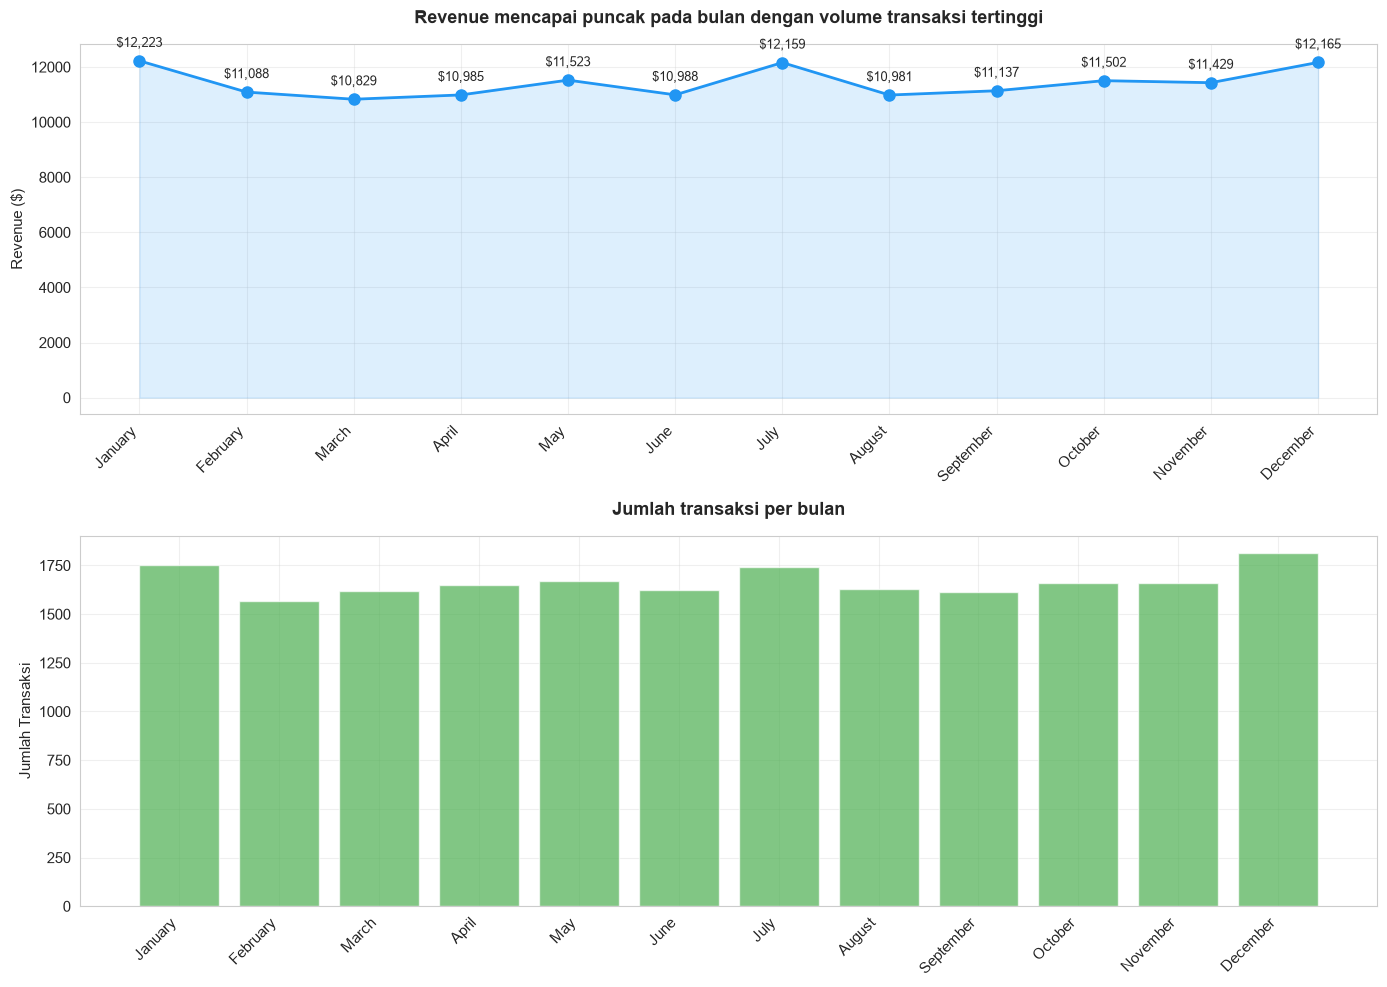

In [9]:
# ============================================================
# Visualisasi Monthly Trend
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue trend
axes[0].plot(monthly['month_name'].astype(str), monthly['revenue'], marker='o', 
             linewidth=2, color='#2196F3', markersize=8)
axes[0].fill_between(range(len(monthly)), monthly['revenue'], alpha=0.15, color='#2196F3')
axes[0].set_title('Revenue mencapai puncak pada bulan dengan volume transaksi tertinggi', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['month_name'].astype(str), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

for i, val in enumerate(monthly['revenue']):
    axes[0].annotate(f'${val:,.0f}', (i, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# Transaction count trend
axes[1].bar(monthly['month_name'].astype(str), monthly['transaction_count'], 
            color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Jumlah transaksi per bulan', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_name'].astype(str), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.3 Daily Sales Trend

 DAILY SALES TREND

Rentang tanggal: 2023-01-01 s/d 2023-12-31
Total hari: 365
Rata-rata revenue harian: $375.37
Rata-rata transaksi harian: 55


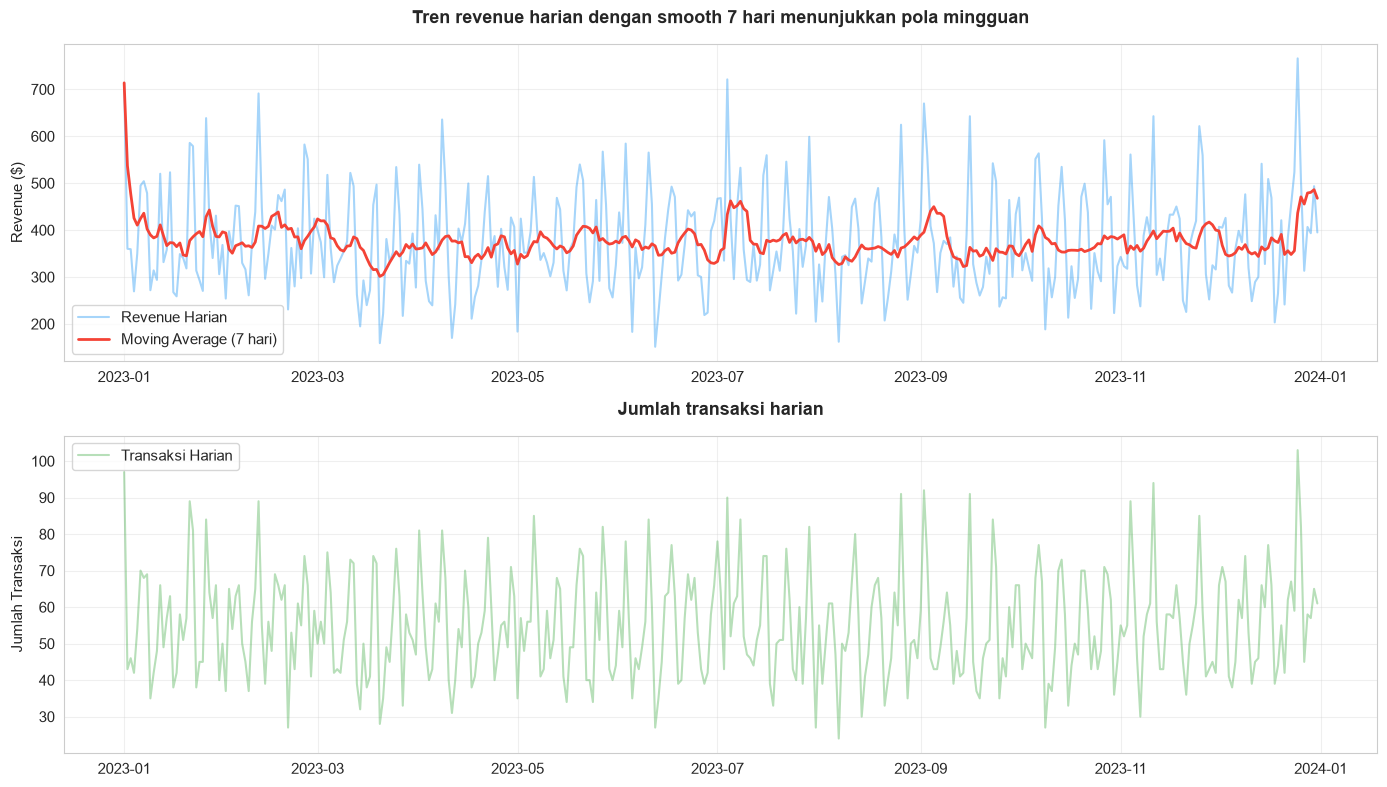

In [10]:
# ============================================================
# 5.3 Daily Sales Trend
# ============================================================

daily = df_eda.groupby(df_eda['timestamp'].dt.date).agg(
    revenue=('total_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    quantity=('quantity', 'sum')
).reset_index()
daily.columns = ['date', 'revenue', 'transaction_count', 'quantity']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

# Rolling average 7 hari
daily['revenue_ma7'] = daily['revenue'].rolling(window=7, min_periods=1).mean()

print('=' * 70)
print(' DAILY SALES TREND')
print('=' * 70)
print(f'\nRentang tanggal: {daily["date"].min().date()} s/d {daily["date"].max().date()}')
print(f'Total hari: {len(daily):,}')
print(f'Rata-rata revenue harian: ${daily["revenue"].mean():,.2f}')
print(f'Rata-rata transaksi harian: {daily["transaction_count"].mean():,.0f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily['date'], daily['revenue'], alpha=0.4, color='#2196F3', label='Revenue Harian')
axes[0].plot(daily['date'], daily['revenue_ma7'], linewidth=2, color='#F44336', label='Moving Average (7 hari)')
axes[0].set_title('Tren revenue harian dengan smooth 7 hari menunjukkan pola mingguan', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily['date'], daily['transaction_count'], alpha=0.4, color='#4CAF50', label='Transaksi Harian')
axes[1].set_title('Jumlah transaksi harian', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Category Contribution

In [11]:
# ============================================================
# 5.4 Category Contribution
# ============================================================

category_contrib = df_eda.groupby('product_category').agg(
    revenue=('total_amount', 'sum'),
    quantity=('quantity', 'sum'),
    transaction_count=('transaction_id', 'count')
).reset_index()

category_contrib['revenue_pct'] = category_contrib['revenue'] / category_contrib['revenue'].sum() * 100
category_contrib['quantity_pct'] = category_contrib['quantity'] / category_contrib['quantity'].sum() * 100
category_contrib['revenue_rank'] = category_contrib['revenue'].rank(ascending=False).astype(int)
category_contrib = category_contrib.sort_values('revenue', ascending=False)

print('=' * 70)
print(' CATEGORY CONTRIBUTION TO REVENUE')
print('=' * 70)
print(f'\n{"Category":<20} {"Revenue":>15} {"% Revenue":>12} {"% Quantity":>12} {"Rank":>6}')
print('-' * 67)
for _, row in category_contrib.iterrows():
    print(f"{row['product_category']:<20} {'$' + f'{row["revenue"]:.2f}':>15} {f'{row["revenue_pct"]:.1f}%':>12} {f'{row["quantity_pct"]:.1f}%':>12} {f'{row["revenue_rank"]}':>6}")

 CATEGORY CONTRIBUTION TO REVENUE

Category                     Revenue    % Revenue   % Quantity   Rank
-------------------------------------------------------------------
Coffee                     $58037.99        42.4%        46.2%      1
Tea                        $29622.10        21.6%        24.6%      2
Sandwich                   $17589.90        12.8%         9.0%      3
Merchandise                $12218.84         8.9%         2.7%      4
Pastry                     $10049.26         7.3%        12.6%      5
Smoothie                    $9491.18         6.9%         4.9%      6


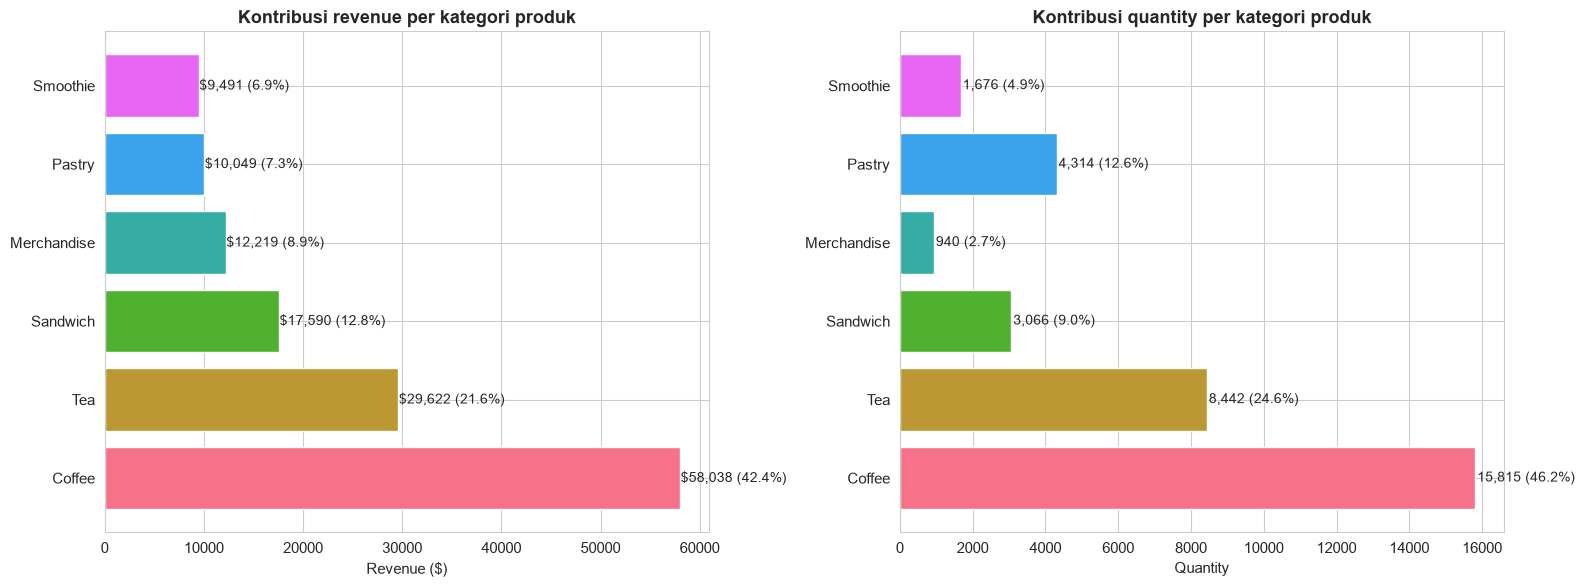

In [12]:
# ============================================================
# Visualisasi Category Contribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_rev = sns.color_palette('husl', len(category_contrib))
axes[0].barh(category_contrib['product_category'], category_contrib['revenue'], 
             color=colors_rev, edgecolor='white')
axes[0].set_title('Kontribusi revenue per kategori produk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
for i, (_, row) in enumerate(category_contrib.iterrows()):
    axes[0].text(row['revenue'] + 50, i, f"${row['revenue']:,.0f} ({row['revenue_pct']:.1f}%)", 
                 va='center', fontsize=10)

axes[1].barh(category_contrib['product_category'], category_contrib['quantity'], 
             color=colors_rev, edgecolor='white')
axes[1].set_title('Kontribusi quantity per kategori produk', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantity')
for i, (_, row) in enumerate(category_contrib.iterrows()):
    axes[1].text(row['quantity'] + 50, i, f"{row['quantity']:,} ({row['quantity_pct']:.1f}%)", 
                 va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5.5 Sales Findings

### Temuan Utama:

1. **Total revenue** dari seluruh transaksi mencapai total yang signifikan dari jumlah transaksi yang besar.

2. **Rata-rata transaction value** lebih tinggi dari median, menunjukkan distribusi right-skewed.

3. **Tren bulanan** menunjukkan variasi revenue antar bulan dengan pola yang perlu dipelajari lebih lanjut.

4. **Kategori produk** dengan kontribusi terbesar mendominasi revenue, sementara kategori lain perlu strategi khusus.

### Business Insight:
- Pola mingguan terlihat jelas pada tren harian, menunjukkan variasi antara hari kerja dan akhir pekan.
- Kategori dengan kontribusi rendah perlu dievaluasi apakah perlu strategi promosi atau penghentian.

### Recommendation Awal:
- Fokuskan promosi pada bulan dengan revenue rendah.
- Tingkatkan stok untuk kategori produk dengan kontribusi terbesar.

---
# 6. Product Analysis

Analisis mendalam terhadap performa produk.

## 6.1 Best-Selling Product

In [13]:
# ============================================================
# 6.1 Best-Selling Product
# ============================================================

product_summary = df_eda.groupby('product_name').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('total_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_unit_price=('unit_price', 'mean')
).reset_index()

product_summary['qty_rank'] = product_summary['total_quantity'].rank(ascending=False).astype(int)
product_summary['rev_rank'] = product_summary['total_revenue'].rank(ascending=False).astype(int)
product_summary['txn_rank'] = product_summary['transaction_count'].rank(ascending=False).astype(int)

print('=' * 70)
print(' TOP 15 PRODUK BERDASARKAN QUANTITY')
print('=' * 70)
top_qty = product_summary.nlargest(15, 'total_quantity')
print(f'\n{"Product":<30} {"Qty":>8} {"Revenue":>14} {"Txn":>8} {"Avg Price":>10}')
print('-' * 72)
for _, row in top_qty.iterrows():
    print(f"{row['product_name']:<30} {f'{row["total_quantity"]:,}':>8} {'$' + f'{row["total_revenue"]:.2f}':>14} {f'{row["transaction_count"]:,}':>8} {'$' + f'{row["avg_unit_price"]:.2f}':>10}")

 TOP 15 PRODUK BERDASARKAN QUANTITY

Product                             Qty        Revenue      Txn  Avg Price
------------------------------------------------------------------------
Medium Cappuccino                 1,163       $4475.58      650      $3.90
Small Mocha                       1,146       $4438.59      637      $3.95
Croissant                         1,137       $2712.26      664      $2.42
Double Espresso                   1,120       $3125.61      650      $2.83
Scone                             1,103       $2316.50      637      $2.12
Blueberry Muffin                  1,093       $3150.27      640      $2.91
Single Espresso                   1,087       $3032.44      622      $2.81
Large Cappuccino                  1,079       $4761.95      629      $4.47
Small Latte                       1,068       $3670.04      635      $3.50
Medium Americano                  1,067       $3066.88      634      $2.91
Small Americano                   1,054       $2739.83      616  

In [14]:
# ============================================================
# Top 10 Produk berdasarkan Revenue
# ============================================================

print('=' * 70)
print(' TOP 10 PRODUK BERDASARKAN REVENUE')
print('=' * 70)
top_rev = product_summary.nlargest(10, 'total_revenue')
print(f'\n{"Rank":<5} {"Product":<30} {"Revenue":>14} {"% Rev":>8} {"Qty":>8}')
print('-' * 67)
for i, (_, row) in enumerate(top_rev.iterrows(), 1):
    pct = row['total_revenue'] / product_summary['total_revenue'].sum() * 100
    print(f"{i:<5} {row['product_name']:<30} {'$' + f'{row["total_revenue"]:.2f}':>14} {f'{pct:.1f}%':>8} {f'{row["total_quantity"]:,}':>8}")

 TOP 10 PRODUK BERDASARKAN REVENUE

Rank  Product                               Revenue    % Rev      Qty
-------------------------------------------------------------------
1     Tote Bag                             $7021.45     5.1%      484
2     Chicken & Avocado Wrap               $6153.62     4.5%      995
3     Vegan Falafel Wrap                   $5959.89     4.3%    1,028
4     Ham & Cheese Croissant               $5476.39     4.0%    1,043
5     Coffee Mug                           $5197.39     3.8%      456
6     Large Mocha                          $4778.44     3.5%      957
7     Large Cappuccino                     $4761.95     3.5%    1,079
8     Large Latte                          $4597.09     3.4%    1,041
9     Medium Cappuccino                    $4475.58     3.3%    1,163
10    Small Mocha                          $4438.59     3.2%    1,146


## 6.2 Lowest-Performing Product

In [15]:
# ============================================================
# 6.2 Lowest-Performing Product
# ============================================================

print('=' * 70)
print(' BOTTOM 10 PRODUK BERDASARKAN REVENUE')
print('=' * 70)
bottom_rev = product_summary.nsmallest(10, 'total_revenue')
print(f'\n{"Rank":<5} {"Product":<30} {"Revenue":>14} {"Qty":>8} {"Avg Price":>10} {"Txn":>8}')
print('-' * 77)
for i, (_, row) in enumerate(bottom_rev.iterrows(), 1):
    print(f"{i:<5} {row['product_name']:<30} {'$' + f'{row["total_revenue"]:.2f}':>14} {f'{row["total_quantity"]:,}':>8} {'$' + f'{row["avg_unit_price"]:.2f}':>10} {f'{row["transaction_count"]:,}':>8}")

print(f'\nCatatan: Produk dengan revenue rendah belum tentu harus dihentikan.')
print(f'Perlu diperiksa: jumlah hari tersedia, harga, jumlah store, dan frekuensi transaksi.')

 BOTTOM 10 PRODUK BERDASARKAN REVENUE

Rank  Product                               Revenue      Qty  Avg Price      Txn
-----------------------------------------------------------------------------
1     Medium Tropical Mango                 $662.29      124      $5.40       70
2     Large Tropical Mango                  $766.57      129      $5.98       74
3     Medium Iced Coffee                    $795.07      236      $3.42      139
4     Medium Pumpkin Spice Latte            $955.98      197      $4.87      123
5     Large Iced Coffee                     $958.45      248      $3.90      140
6     Large Pumpkin Spice Latte            $1251.00      227      $5.59      129
7     Small Green Tea                      $1430.86      599      $2.43      368
8     Small Earl Grey                      $1732.80      720      $2.43      417
9     Medium Earl Grey                     $1835.21      687      $2.72      374
10    Chocolate Chip Cookie                $1870.23      981      $1.95  

## 6.3 Product Category Performance

In [16]:
# ============================================================
# 6.3 Product Category Performance
# ============================================================

cat_perf = df_eda.groupby('product_category').agg(
    revenue=('total_amount', 'sum'),
    quantity=('quantity', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_unit_price=('unit_price', 'mean'),
    avg_transaction_value=('total_amount', 'mean')
).reset_index()

cat_perf = cat_perf.sort_values('revenue', ascending=False)

print('=' * 70)
print(' PRODUCT CATEGORY PERFORMANCE')
print('=' * 70)
print(f'\n{"Category":<18} {"Revenue":>14} {"Qty":>10} {"Txn":>8} {"Avg Price":>10} {"Avg ATV":>10}')
print('-' * 72)
for _, row in cat_perf.iterrows():
    print(f"{row['product_category']:<18} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["quantity"]:,}':>10} {f'{row["transaction_count"]:,}':>8} {'$' + f'{row["avg_unit_price"]:.2f}':>10} {'$' + f'{row["avg_transaction_value"]:.2f}':>10}")

 PRODUCT CATEGORY PERFORMANCE

Category                  Revenue        Qty      Txn  Avg Price    Avg ATV
------------------------------------------------------------------------
Coffee                  $58037.99     15,815    9,216      $3.72      $6.30
Tea                     $29622.10      8,442    4,963      $3.55      $5.97
Sandwich                $17589.90      3,066    1,781      $5.82      $9.88
Merchandise             $12218.84        940      538     $13.21     $22.71
Pastry                  $10049.26      4,314    2,524      $2.36      $3.98
Smoothie                 $9491.18      1,676      978      $5.73      $9.70


## 6.4 Discount Analysis by Product

In [17]:
# ============================================================
# 6.4 Discount Analysis by Product
# ============================================================

print('=' * 70)
print(' DISCOUNT ANALYSIS BY PRODUCT')
print('=' * 70)

discount_by_cat = df_eda.groupby(['product_category', 'discount_applied']).agg(
    revenue=('total_amount', 'sum'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean'),
    count=('transaction_id', 'count')
).reset_index()

print('\nDistribusi Transaksi Diskon per Kategori:')
for cat in df_eda['product_category'].unique():
    cat_data = discount_by_cat[discount_by_cat['product_category'] == cat]
    disc = cat_data[cat_data['discount_applied'] == True]
    no_disc = cat_data[cat_data['discount_applied'] == False]
    total = disc['count'].sum() + no_disc['count'].sum()
    disc_pct = disc['count'].sum() / total * 100 if total > 0 else 0
    print(f'\n  {cat}:')
    if len(disc) > 0:
        print(f"    Diskon: {disc['count'].values[0]:,} transaksi ({disc_pct:.1f}%) - Avg: ${disc['avg_transaction'].values[0]:.2f}")
    if len(no_disc) > 0:
        print(f"    Tanpa Diskon: {no_disc['count'].values[0]:,} transaksi ({100-disc_pct:.1f}%) - Avg: ${no_disc['avg_transaction'].values[0]:.2f}")

# Ringkasan dampak diskon
print(f'\n{"="*50}')
print(f'RINGKASAN DAMPAK DISKON')
print(f'{"="*50}')
disc_true = df_eda[df_eda['discount_applied'] == True]
disc_false = df_eda[df_eda['discount_applied'] == False]
print(f'\nDengan Diskon: {len(disc_true):,} transaksi ({len(disc_true)/len(df_eda)*100:.1f}%)')
print(f'  - Total Revenue: ${disc_true["total_amount"].sum():,.2f}')
print(f'  - Rata-rata: ${disc_true["total_amount"].mean():.2f}')
print(f'\nTanpa Diskon: {len(disc_false):,} transaksi ({len(disc_false)/len(df_eda)*100:.1f}%)')
print(f'  - Total Revenue: ${disc_false["total_amount"].sum():,.2f}')
print(f'  - Rata-rata: ${disc_false["total_amount"].mean():.2f}')

print(f'\nCatatan: Perbandingan rata-rata transaction value antara diskon dan non-diskon')
print(f'belum bisa menyimpulkan bahwa diskon menyebabkan kenaikan penjualan.')
print(f'Perlu analisis lebih lanjut dengan kontrol variabel lain.')

 DISCOUNT ANALYSIS BY PRODUCT

Distribusi Transaksi Diskon per Kategori:

  Coffee:
    Diskon: 9,216 transaksi (100.0%) - Avg: $6.30

  Tea:
    Diskon: 4,963 transaksi (100.0%) - Avg: $5.97

  Sandwich:
    Diskon: 1,781 transaksi (100.0%) - Avg: $9.88

  Smoothie:
    Diskon: 978 transaksi (100.0%) - Avg: $9.70

  Pastry:
    Diskon: 2,524 transaksi (100.0%) - Avg: $3.98

  Merchandise:
    Diskon: 538 transaksi (100.0%) - Avg: $22.71

RINGKASAN DAMPAK DISKON

Dengan Diskon: 20,000 transaksi (100.0%)
  - Total Revenue: $137,009.27
  - Rata-rata: $6.85

Tanpa Diskon: 0 transaksi (0.0%)
  - Total Revenue: $0.00
  - Rata-rata: $nan

Catatan: Perbandingan rata-rata transaction value antara diskon dan non-diskon
belum bisa menyimpulkan bahwa diskon menyebabkan kenaikan penjualan.
Perlu analisis lebih lanjut dengan kontrol variabel lain.


## 6.5 Product Findings

### Temuan Utama:

1. **Produk terlaris** berdasarkan quantity dan revenue menunjukkan dominasi beberapa produk tertentu.

2. **Produk dengan revenue rendah** perlu dianalisis lebih lanjut sebelum diputuskan untuk dihentikan.

3. **Distribusi diskon** bervariasi antar kategori produk.

### Rekomendasi:
- Prioritaskan produk dengan revenue dan quantity tinggi untuk stok dan promosi.
- Evaluasi produk dengan performa rendah berdasarkan frekuensi dan margin.
- Gunakan data diskon untuk mengoptimalkan strategi promosi.

---
# 7. Customer Analysis

Analisis perilaku dan segmentasi pelanggan.

## 7.1 Customer Value

In [18]:
# ============================================================
# 7.1 Customer Value
# ============================================================

customer_value = df_eda.groupby('customer_id').agg(
    total_revenue=('total_amount', 'sum'),
    total_transactions=('transaction_id', 'count'),
    total_quantity=('quantity', 'sum'),
    avg_transaction_value=('total_amount', 'mean')
).reset_index()

# Ambil customer_segment dari df_eda (sudah di-merge)
cust_segment = df_eda.groupby('customer_id')['customer_segment'].first().reset_index()
customer_value = customer_value.merge(cust_segment, on='customer_id', how='left')

customer_value = customer_value.sort_values('total_revenue', ascending=False)

print('=' * 70)
print(' TOP 15 PELANGGAN BERDASARKAN TOTAL REVENUE')
print('=' * 70)
print(f'\n{"Rank":<5} {"Customer ID":<15} {"Revenue":>14} {"Txn":>8} {"Qty":>8} {"Avg ATV":>12}')
print('-' * 64)
for i, (_, row) in enumerate(customer_value.head(15).iterrows(), 1):
    print(f"{i:<5} {row['customer_id']:<15} {'$' + f'{row["total_revenue"]:.2f}':>14} {f'{row["total_transactions"]:,}':>8} {f'{row["total_quantity"]:,}':>8} {'$' + f'{row["avg_transaction_value"]:.2f}':>12}")

print(f'\nStatistik Pelanggan:')
print(f'  Total Pelanggan: {len(customer_value):,}')
print(f'  Rata-rata Revenue per Pelanggan: ${customer_value["total_revenue"].mean():.2f}')
print(f'  Median Revenue per Pelanggan: ${customer_value["total_revenue"].median():.2f}')
top10_pct = customer_value.head(int(len(customer_value)*0.1))['total_revenue'].sum()/customer_value['total_revenue'].sum()*100
print(f'  Top 10% Pelanggan menyumbang: {top10_pct:.1f}% revenue')


 TOP 15 PELANGGAN BERDASARKAN TOTAL REVENUE

Rank  Customer ID            Revenue      Txn      Qty      Avg ATV
----------------------------------------------------------------
1     g0l3rtz5               $117.40        2        9       $58.70
2     cy2c11bd               $109.56        3       14       $36.52
3     gb205hu0                $91.00        2       10       $45.50
4     zvvmi177                $84.60        1        6       $84.60
5     164bckbr                $82.80        1        6       $82.80
6     zuumcnjy                $81.00        1        5       $81.00
7     x3kl5x1x                $80.00        1        5       $80.00
8     ga9ta76n                $79.89        2        7       $39.95
9     za4aeijt                $75.00        1        5       $75.00
10    azmh5ajf                $75.00        1        4       $75.00
11    vwhholi5                $75.00        4       14       $18.75
12    g6ooh1xa                $74.91        2       12       $37.45
13    

## 7.2 Customer Frequency

In [19]:
# ============================================================
# 7.2 Customer Frequency
# ============================================================

def categorize_frequency(txn_count):
    if txn_count == 1:
        return 'One-time (1)'
    elif txn_count <= 3:
        return 'Occasional (2-3)'
    elif txn_count <= 7:
        return 'Frequent (4-7)'
    else:
        return 'Loyal (8+)'

customer_value['frequency_group'] = customer_value['total_transactions'].apply(categorize_frequency)

freq_summary = customer_value.groupby('frequency_group').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_revenue=('total_revenue', 'mean'),
    avg_txn=('total_transactions', 'mean')
).reset_index()

freq_order = ['One-time (1)', 'Occasional (2-3)', 'Frequent (4-7)', 'Loyal (8+)']
freq_summary['frequency_group'] = pd.Categorical(freq_summary['frequency_group'], categories=freq_order, ordered=True)
freq_summary = freq_summary.sort_values('frequency_group')

print('=' * 70)
print(' CUSTOMER FREQUENCY SEGMENTATION')
print('=' * 70)
print(f'\n{"Segment":<22} {"Customers":>12} {"% Cust":>10} {"Revenue":>16} {"% Rev":>10} {"Avg Txn":>10}')
print('-' * 82)
for _, row in freq_summary.iterrows():
    cust_pct = row['customer_count']/len(customer_value)*100
    rev_pct = row['total_revenue']/customer_value['total_revenue'].sum()*100
    print(f"{row['frequency_group']:<22} {f'{row["customer_count"]:,}':>12} {f'{cust_pct:.1f}%':>10} {'$' + f'{row["total_revenue"]:,.2f}':>16} {f'{rev_pct:.1f}%':>10} {f'{row["avg_txn"]:.1f}':>10}")

 CUSTOMER FREQUENCY SEGMENTATION

Segment                   Customers     % Cust          Revenue      % Rev    Avg Txn
----------------------------------------------------------------------------------
One-time (1)                 18,664      97.0%      $127,662.38      93.2%        1.0
Occasional (2-3)                557       2.9%        $8,464.26       6.2%        2.2
Frequent (4-7)                   29       0.2%          $882.63       0.6%        4.1


## 7.3 Age Group Analysis

 AGE GROUP ANALYSIS

Age Group                 Revenue    % Rev        Txn      Avg ATV
----------------------------------------------------------------
25-34                   $31645.96    23.1%      4,617        $6.85
35-44                   $25414.96    18.5%      3,737        $6.80
55-64                   $20030.96    14.6%      2,832        $7.07
18-24                   $20028.00    14.6%      2,888        $6.93
45-54                   $19310.37    14.1%      2,906        $6.64
65+                     $13111.03     9.6%      1,944        $6.74
Unknown                  $7467.99     5.5%      1,076        $6.94


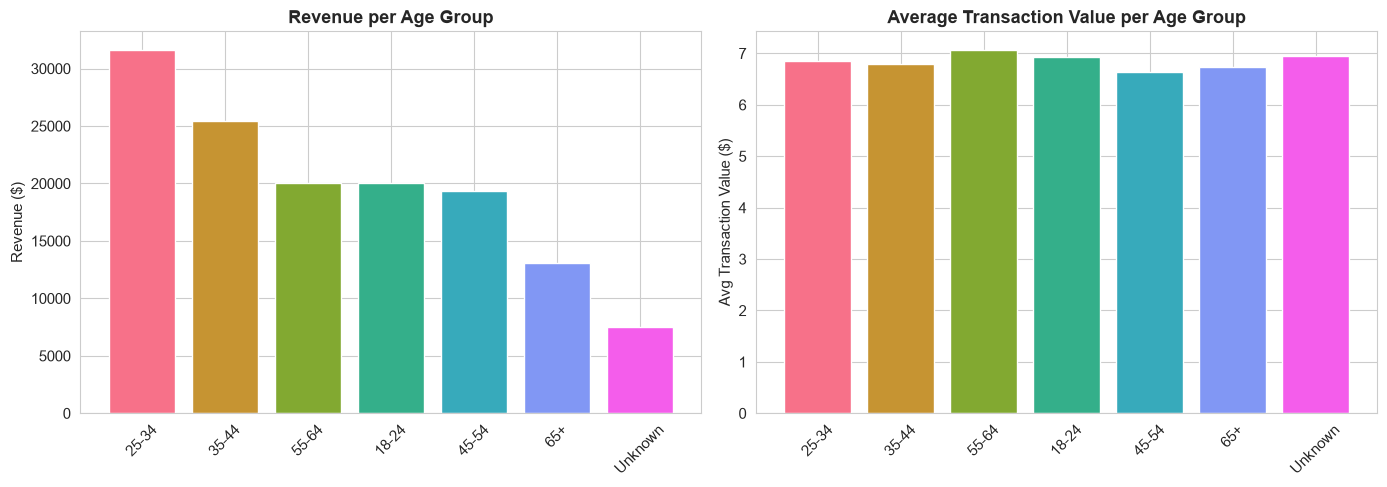

In [20]:
# ============================================================
# 7.3 Age Group Analysis
# ============================================================

age_analysis = df_eda.groupby('customer_age_group').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean')
).reset_index()

age_analysis['rev_pct'] = age_analysis['revenue'] / age_analysis['revenue'].sum() * 100
age_analysis = age_analysis.sort_values('revenue', ascending=False)

print('=' * 70)
print(' AGE GROUP ANALYSIS')
print('=' * 70)
print(f'\n{"Age Group":<18} {"Revenue":>14} {"% Rev":>8} {"Txn":>10} {"Avg ATV":>12}')
print('-' * 64)
for _, row in age_analysis.iterrows():
    print(f"{row['customer_age_group']:<18} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["rev_pct"]:.1f}%':>8} {f'{row["transactions"]:,}':>10} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_analysis['customer_age_group'], age_analysis['revenue'], color=sns.color_palette('husl', len(age_analysis)))
axes[0].set_title('Revenue per Age Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(age_analysis['customer_age_group'], age_analysis['avg_transaction'], color=sns.color_palette('husl', len(age_analysis)))
axes[1].set_title('Average Transaction Value per Age Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Transaction Value ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7.4 Gender Analysis

In [21]:
# ============================================================
# 7.4 Gender Analysis
# ============================================================

gender_analysis = df_eda.groupby('customer_gender').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean'),
    n_customers=('customer_id', 'nunique')
).reset_index()

print('=' * 70)
print(' GENDER ANALYSIS')
print('=' * 70)
print(f'\n{"Gender":<15} {"Revenue":>14} {"% Rev":>8} {"Txn":>10} {"Customers":>12} {"Avg ATV":>10}')
print('-' * 71)
for _, row in gender_analysis.iterrows():
    pct = row['revenue'] / gender_analysis['revenue'].sum() * 100
    print(f"{row['customer_gender']:<15} {'$' + f'{row["revenue"]:.2f}':>14} {f'{pct:.1f}%':>8} {f'{row["transactions"]:,}':>10} {f'{row["n_customers"]:,}':>12} {'$' + f'{row["avg_transaction"]:.2f}':>10}")

 GENDER ANALYSIS

Gender                 Revenue    % Rev        Txn    Customers    Avg ATV
-----------------------------------------------------------------------
Female               $62519.72    45.6%      9,123        8,788      $6.85
Male                 $62098.06    45.3%      9,019        8,725      $6.89
Non-binary            $2553.39     1.9%        373          362      $6.85
Prefer not to say       $2762.40     2.0%        413          390      $6.69
Unknown               $7075.70     5.2%      1,072        1,068      $6.60


## 7.5 Customer Segment Analysis

In [22]:
# ============================================================
# 7.5 Customer Segment Analysis
# ============================================================

segment_analysis = df_eda.groupby('customer_segment').agg(
    n_customers=('customer_id', 'nunique'),
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    avg_transaction=('total_amount', 'mean'),
    total_spending=('total_spending', 'mean')
).reset_index()

segment_analysis['rev_pct'] = segment_analysis['revenue'] / segment_analysis['revenue'].sum() * 100

print('=' * 70)
print(' CUSTOMER SEGMENT ANALYSIS')
print('=' * 70)
print(f'\n{"Segment":<18} {"Customers":>12} {"Revenue":>14} {"% Rev":>8} {"Avg ATV":>10} {"Avg Spend":>12}')
print('-' * 76)
for _, row in segment_analysis.iterrows():
    print(f"{row['customer_segment']:<18} {f'{row["n_customers"]:,}':>12} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["rev_pct"]:.1f}%':>8} {'$' + f'{row["avg_transaction"]:.2f}':>10} {'$' + f'{row["total_spending"]:.2f}':>12}")

print(f'\nRepeat Behavior per Segment:')
for seg in segment_analysis['customer_segment']:
    seg_data = customer_value[customer_value['customer_segment'] == seg]
    repeat = seg_data[seg_data['total_transactions'] > 1]
    print(f'  {seg}: {len(repeat):,}/{len(seg_data):,} pelanggan repeat ({len(repeat)/len(seg_data)*100:.1f}%)')


 CUSTOMER SEGMENT ANALYSIS

Segment               Customers        Revenue    % Rev    Avg ATV    Avg Spend
----------------------------------------------------------------------------
High Value                6,524      $86024.32    62.8%     $11.95       $13.74
Low Value                 6,375      $18582.70    13.6%      $2.91        $2.92
Medium Value              6,351      $32402.25    23.6%      $5.04        $5.11

Repeat Behavior per Segment:
  High Value: 513/6,524 pelanggan repeat (7.9%)
  Low Value: 1/6,375 pelanggan repeat (0.0%)
  Medium Value: 72/6,351 pelanggan repeat (1.1%)


## 7.6 Customer Findings

### Temuan Utama:

1. **Top pelanggan** menyumbang proporsi revenue yang signifikan dari total.

2. **Frekuensi transaksi** menunjukkan distribusi pelanggan one-time vs repeat customer.

3. **Segmentasi pelanggan** berdasarkan spending menunjukkan perbedaan kontribusi antar segmen.

4. **Age group** dengan revenue tertinggi menjadi target utama pemasaran.

### Rekomendasi Pemasaran:
- Buat program loyalitas untuk pelanggan frequent dan loyal.
- Targetkan promosi untuk mengubah one-time menjadi repeat customer.
- Personalisasi penawaran berdasarkan segmen pelanggan.

---
# 8. Region and Store Analysis

Analisis performa berdasarkan lokasi dan toko.

## 8.1 Country Performance

In [23]:
# ============================================================
# 8.1 Country Performance
# ============================================================

country_perf = df_eda.groupby('country').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean'),
    n_stores=('store_id', 'nunique')
).reset_index()

country_perf = country_perf.sort_values('revenue', ascending=False)

print('=' * 70)
print(' COUNTRY PERFORMANCE')
print('=' * 70)
print(f'\n{"Country":<12} {"Revenue":>14} {"Txn":>10} {"Stores":>8} {"Avg ATV":>12}')
print('-' * 58)
for _, row in country_perf.iterrows():
    print(f"{row['country']:<12} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["n_stores"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

 COUNTRY PERFORMANCE

Country             Revenue        Txn   Stores      Avg ATV
----------------------------------------------------------
USA               $47694.86      6,685       15        $7.13
AUS               $33263.25      4,392       10        $7.57
CAN               $30278.20      4,571       10        $6.62
UK                $25772.96      4,352       10        $5.92


## 8.2 City Performance

In [24]:
# ============================================================
# 8.2 City Performance
# ============================================================

city_perf = df_eda.groupby('city').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean'),
    n_stores=('store_id', 'nunique')
).reset_index()

city_perf = city_perf.sort_values('revenue', ascending=False)

print('=' * 70)
print(' CITY PERFORMANCE (Top 15)')
print('=' * 70)
print(f'\n{"City":<20} {"Revenue":>14} {"Txn":>10} {"Stores":>8} {"Avg ATV":>12}')
print('-' * 66)
for _, row in city_perf.head(15).iterrows():
    print(f"{row['city']:<20} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["n_stores"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

print(f'\n--- Kota Terendah (Bottom 5) ---')
for _, row in city_perf.tail(5).iterrows():
    print(f"{row['city']:<20} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["n_stores"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

 CITY PERFORMANCE (Top 15)

City                        Revenue        Txn   Stores      Avg ATV
------------------------------------------------------------------
New York                  $16789.12      2,288        5        $7.34
Melbourne                 $16650.31      2,181        5        $7.63
Sydney                    $16612.94      2,211        5        $7.51
Los Angeles               $15596.14      2,195        5        $7.11
Chicago                   $15309.60      2,202        5        $6.95
Toronto                   $15209.40      2,284        5        $6.66
Vancouver                 $15068.80      2,287        5        $6.59
London                    $13538.02      2,251        5        $6.01
Manchester                $12234.94      2,101        5        $5.82

--- Kota Terendah (Bottom 5) ---
Chicago                   $15309.60      2,202        5        $6.95
Toronto                   $15209.40      2,284        5        $6.66
Vancouver                 $15068.80      2,

## 8.3 Store Performance

In [25]:
# ============================================================
# 8.3 Store Performance
# ============================================================

store_perf = df_eda.groupby(['store_id', 'city', 'store_type']).agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean')
).reset_index()

store_perf = store_perf.sort_values('revenue', ascending=False)

print('=' * 70)
print(' STORE PERFORMANCE (Top 10)')
print('=' * 70)
print(f'\n{"Store":>6} {"City":<20} {"Type":<18} {"Revenue":>14} {"Txn":>8} {"Avg ATV":>10}')
print('-' * 78)
for _, row in store_perf.head(10).iterrows():
    print(f"{f'{row["store_id"]}':>6} {row['city']:<20} {row['store_type']:<18} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>10}")

print(f'\n--- Store Terendah (Bottom 5) ---')
for _, row in store_perf.tail(5).iterrows():
    print(f"{f'{row["store_id"]}':>6} {row['city']:<20} {row['store_type']:<18} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>10}")

 STORE PERFORMANCE (Top 10)

 Store City                 Type                      Revenue      Txn    Avg ATV
------------------------------------------------------------------------------
     8 Los Angeles          Airport                  $3982.38      458      $8.70
     2 New York             Airport                  $3743.64      410      $9.13
    36 Toronto              Airport                  $3645.28      466      $7.82
    28 Sydney               Mall Kiosk               $3553.22      468      $7.59
    12 Chicago              Airport                  $3534.05      436      $8.11
     1 New York             Standalone               $3470.33      491      $7.07
    32 Melbourne            Standalone               $3416.14      441      $7.75
    34 Melbourne            Mall Kiosk               $3415.15      471      $7.25
    33 Melbourne            Standalone               $3412.85      449      $7.60
    26 Sydney               Mall Kiosk               $3330.51      448  

## 8.4 Store Type Analysis

In [26]:
# ============================================================
# 8.4 Store Type Analysis
# ============================================================

store_type_perf = df_eda.groupby('store_type').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean'),
    n_stores=('store_id', 'nunique')
).reset_index()

store_type_perf = store_type_perf.sort_values('revenue', ascending=False)

print('=' * 70)
print(' STORE TYPE PERFORMANCE')
print('=' * 70)
print(f'\n{"Store Type":<18} {"Revenue":>14} {"Txn":>10} {"Stores":>8} {"Avg ATV":>10}')
print('-' * 62)
for _, row in store_type_perf.iterrows():
    print(f"{row['store_type']:<18} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["n_stores"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>10}")

 STORE TYPE PERFORMANCE

Store Type                Revenue        Txn   Stores    Avg ATV
--------------------------------------------------------------
Standalone              $81934.38     12,347       28      $6.64
Mall Kiosk              $40169.54      5,883       13      $6.83
Airport                 $14905.35      1,770        4      $8.42


## 8.5 Region Heatmap

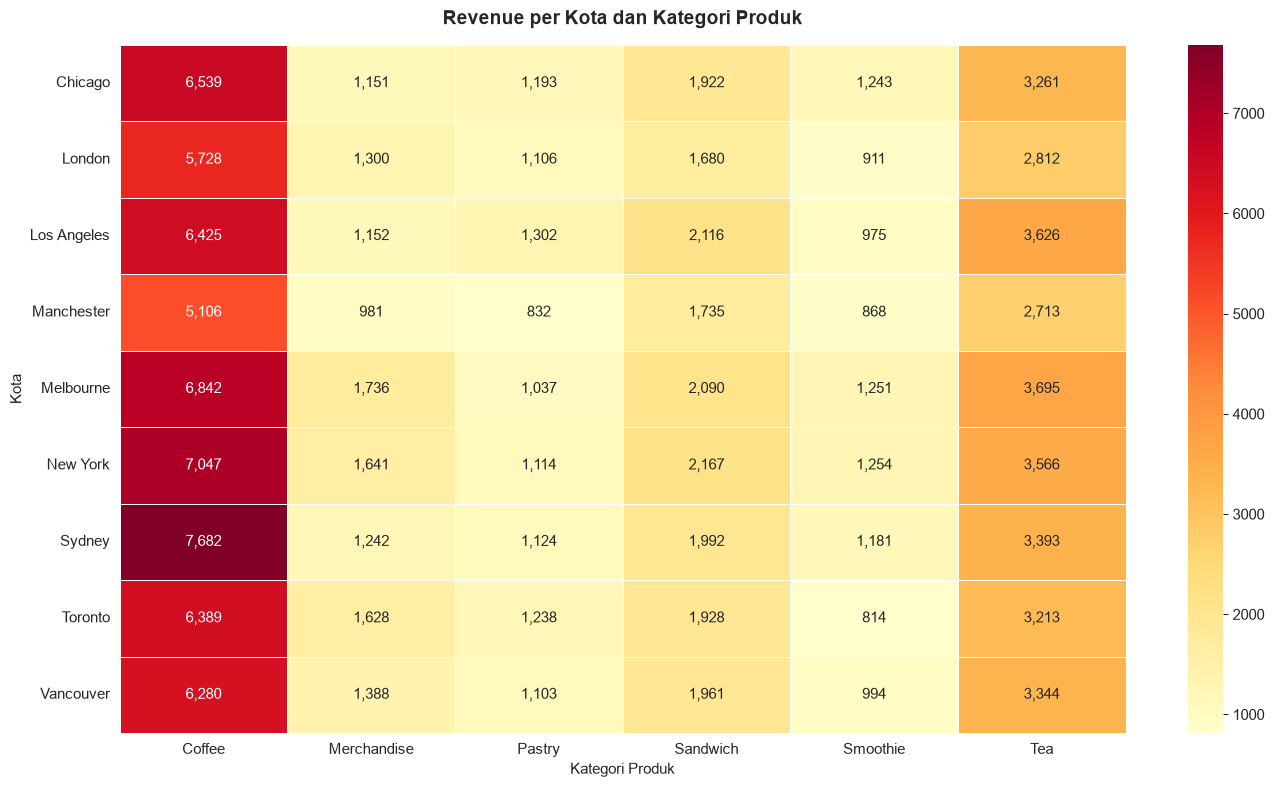

In [27]:
# ============================================================
# 8.5 Region Heatmap
# ============================================================

pivot_data = df_eda.pivot_table(
    values='total_amount',
    index='city',
    columns='product_category',
    aggfunc='sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_data, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Revenue per Kota dan Kategori Produk', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Kota')
ax.set_xlabel('Kategori Produk')
plt.tight_layout()
plt.show()

## 8.6 Region Findings

### Temuan Utama:

1. **Negara/kota terbaik** berdasarkan revenue perlu diidentifikasi untuk strategi ekspansi.

2. **Store type** menunjukkan perbedaan performa antar tipe toko.

3. **Heatmap** menunjukkan interaksi antara lokasi dan kategori produk.

### Rekomendasi:
- Investasi pada wilayah dengan revenue tinggi dan pertumbuhan positif.
- Evaluasi store dengan performa rendah.
- Sesuaikan mix produk berdasarkan preferensi lokal.

---
# 9. Time Analysis

Analisis pola waktu penjualan - sangat penting untuk Coffee Shop.

## 9.1 Monthly Pattern

In [28]:
# ============================================================
# 9.1 Monthly Pattern
# ============================================================

monthly_pattern = df_eda.groupby(['month', 'month_name']).agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum')
).reset_index()

monthly_pattern = monthly_pattern.sort_values('month')

print('=' * 70)
print(' MONTHLY PATTERN')
print('=' * 70)
print(f'\n{"Month":<15} {"Revenue":>14} {"Txn":>10} {"Qty":>10}')
print('-' * 51)
for _, row in monthly_pattern.iterrows():
    print(f"{row['month_name']:<15} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["quantity"]:,}':>10}")

max_month = monthly_pattern.loc[monthly_pattern['revenue'].idxmax()]
min_month = monthly_pattern.loc[monthly_pattern['revenue'].idxmin()]
print(f'\nBulan Tertinggi: {max_month["month_name"]} (${max_month["revenue"]:,.2f})')
print(f'Bulan Terendah: {min_month["month_name"]} (${min_month["revenue"]:,.2f})')
diff_pct = (max_month['revenue'] - min_month['revenue'])/min_month['revenue']*100
print(f'Selisih: ${max_month["revenue"] - min_month["revenue"]:,.2f} ({diff_pct:.1f}% lebih tinggi)')

 MONTHLY PATTERN

Month                  Revenue        Txn        Qty
---------------------------------------------------
January              $12222.76      1,754      3,034
February             $11088.17      1,567      2,708
March                $10828.63      1,617      2,739
April                $10985.00      1,648      2,819
May                  $11522.54      1,669      2,919
June                 $10988.05      1,625      2,763
July                 $12158.97      1,743      2,959
August               $10981.32      1,631      2,813
September            $11136.90      1,614      2,728
October              $11502.45      1,660      2,855
November             $11429.06      1,660      2,815
December             $12165.42      1,812      3,101

Bulan Tertinggi: January ($12,222.76)
Bulan Terendah: March ($10,828.63)
Selisih: $1,394.13 (12.9% lebih tinggi)


## 9.2 Day-of-Week Pattern

 DAY-OF-WEEK PATTERN

Day                 Revenue        Txn      Qty      Avg ATV
----------------------------------------------------------
Monday            $14534.06      2,061    3,628        $7.05
Tuesday           $16037.23      2,347    4,009        $6.83
Wednesday         $16709.48      2,448    4,165        $6.83
Thursday          $19144.05      2,843    4,765        $6.73
Friday            $20321.46      3,029    5,131        $6.71
Saturday          $26675.00      3,925    6,730        $6.80
Sunday            $23587.99      3,347    5,825        $7.05


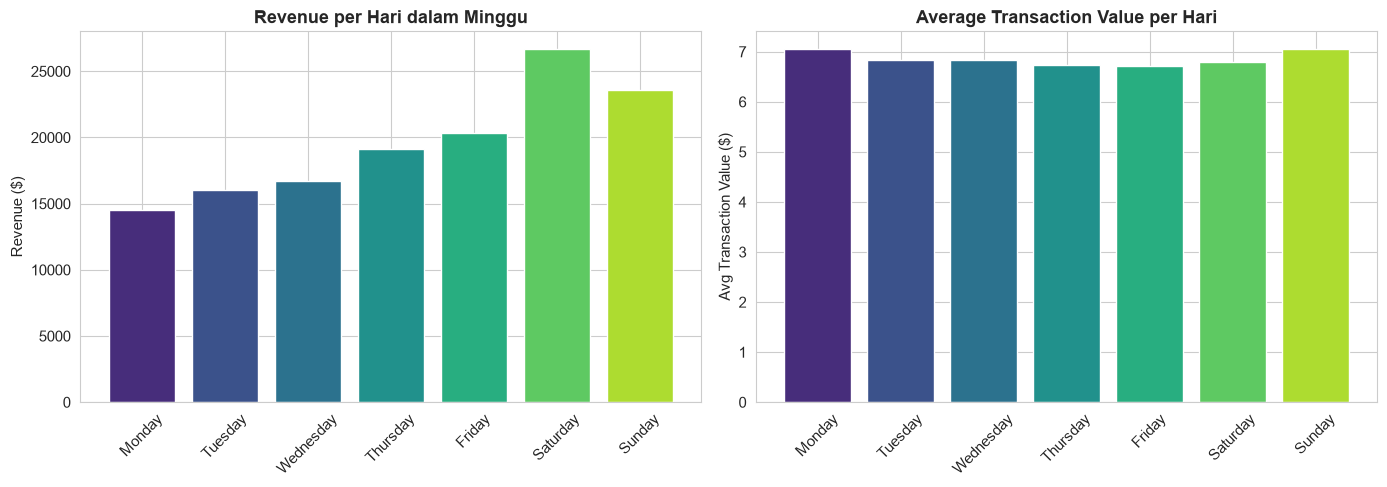

In [29]:
# ============================================================
# 9.2 Day-of-Week Pattern
# ============================================================

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_pattern = df_eda.groupby('day_name').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean')
).reset_index()

dow_pattern['day_name'] = pd.Categorical(dow_pattern['day_name'], categories=day_order, ordered=True)
dow_pattern = dow_pattern.sort_values('day_name')

print('=' * 70)
print(' DAY-OF-WEEK PATTERN')
print('=' * 70)
print(f'\n{"Day":<12} {"Revenue":>14} {"Txn":>10} {"Qty":>8} {"Avg ATV":>12}')
print('-' * 58)
for _, row in dow_pattern.iterrows():
    print(f"{row['day_name']:<12} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {f'{row["quantity"]:,}':>8} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_pattern['day_name'].astype(str), dow_pattern['revenue'], color=sns.color_palette('viridis', 7))
axes[0].set_title('Revenue per Hari dalam Minggu', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dow_pattern['day_name'].astype(str), dow_pattern['avg_transaction'], color=sns.color_palette('viridis', 7))
axes[1].set_title('Average Transaction Value per Hari', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Transaction Value ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9.3 Hourly Pattern

In [30]:
# ============================================================
# 9.3 Hourly Pattern
# ============================================================

hourly_pattern = df_eda.groupby('hour').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean')
).reset_index()

print('=' * 70)
print(' HOURLY PATTERN')
print('=' * 70)
print(f'\n{"Hour":<6} {"Revenue":>14} {"Txn":>10} {"Avg ATV":>12}')
print('-' * 44)
for _, row in hourly_pattern.iterrows():
    print(f"{f'{int(row["hour"]):02d}:00':<6} {'$' + f'{row["revenue"]:.2f}':>14} {f'{row["transactions"]:,}':>10} {'$' + f'{row["avg_transaction"]:.2f}':>12}")

peak_hour = hourly_pattern.loc[hourly_pattern['transactions'].idxmax()]
off_peak_hour = hourly_pattern.loc[hourly_pattern['transactions'].idxmin()]
peak_rev_hour = hourly_pattern.loc[hourly_pattern['revenue'].idxmax()]
peak_atv_hour = hourly_pattern.loc[hourly_pattern['avg_transaction'].idxmax()]

print(f'\nPeak Hour (transaksi): {int(peak_hour["hour"]):02d}:00 ({peak_hour["transactions"]:,} transaksi)')
print(f'Off-Peak Hour: {int(off_peak_hour["hour"]):02d}:00 ({off_peak_hour["transactions"]:,} transaksi)')
print(f'Peak Hour (revenue): {int(peak_rev_hour["hour"]):02d}:00 (${peak_rev_hour["revenue"]:,.2f})')
print(f'Peak Hour (ATV): {int(peak_atv_hour["hour"]):02d}:00 (${peak_atv_hour["avg_transaction"]:.2f})')

 HOURLY PATTERN

Hour          Revenue        Txn      Avg ATV
--------------------------------------------
00:00        $2076.77      369.0        $5.63
01:00        $1181.58      182.0        $6.49
02:00         $891.24      165.0        $5.40
03:00        $1112.49      205.0        $5.43
04:00        $1231.42      203.0        $6.07
05:00        $2226.73      386.0        $5.77
06:00        $5368.02      924.0        $5.81
07:00       $14921.35    1,834.0        $8.14
08:00       $18213.56    2,243.0        $8.12
09:00       $15379.18    1,879.0        $8.18
10:00       $13201.53    1,550.0        $8.52
11:00        $7916.67    1,376.0        $5.75
12:00        $8200.50    1,124.0        $7.30
13:00        $6631.80      919.0        $7.22
14:00        $6504.06    1,162.0        $5.60
15:00        $8776.23    1,481.0        $5.93
16:00        $7559.75    1,296.0        $5.83
17:00        $5599.87      966.0        $5.80
18:00        $3345.35      576.0        $5.81
19:00        $2153

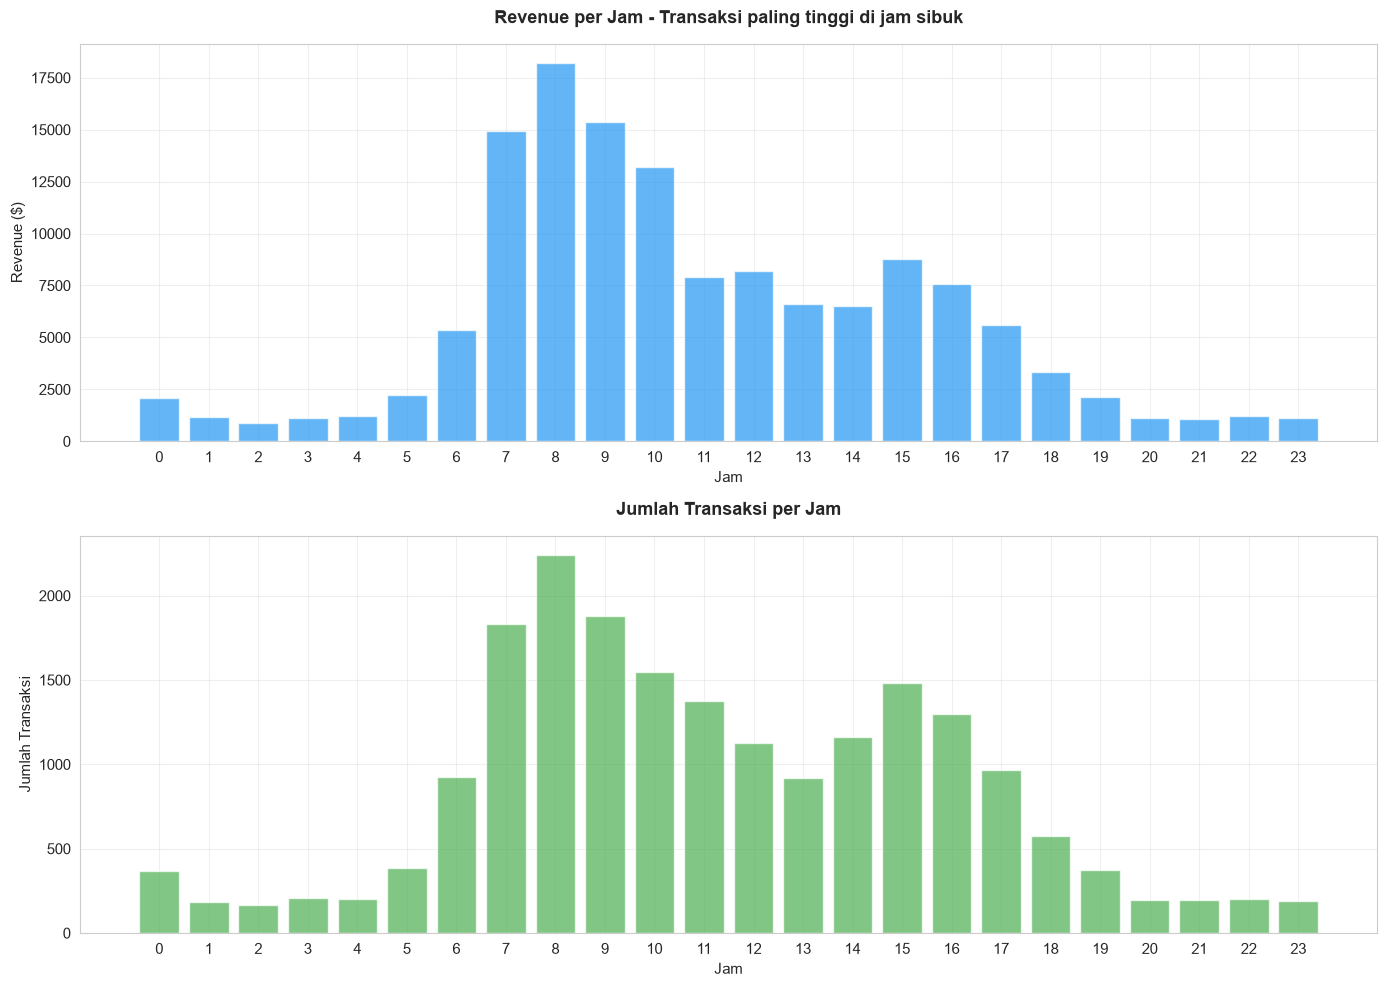

In [31]:
# ============================================================
# Visualisasi Hourly Pattern
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].bar(hourly_pattern['hour'], hourly_pattern['revenue'], color='#2196F3', alpha=0.7)
axes[0].set_title('Revenue per Jam - Transaksi paling tinggi di jam sibuk', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('Jam')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

axes[1].bar(hourly_pattern['hour'], hourly_pattern['transactions'], color='#4CAF50', alpha=0.7)
axes[1].set_title('Jumlah Transaksi per Jam', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xlabel('Jam')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9.4 Weekday vs Weekend

In [32]:
# ============================================================
# 9.4 Weekday vs Weekend
# ============================================================

ww_analysis = df_eda.groupby('is_weekend').agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count'),
    quantity=('quantity', 'sum'),
    avg_transaction=('total_amount', 'mean')
).reset_index()

ww_analysis['label'] = ww_analysis['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

n_weekdays = df_eda[~df_eda['is_weekend']]['timestamp'].dt.date.nunique()
n_weekends = df_eda[df_eda['is_weekend']]['timestamp'].dt.date.nunique()

print('=' * 70)
print(' WEEKDAY VS WEEKEND COMPARISON')
print('=' * 70)

wd = ww_analysis[ww_analysis['is_weekend'] == False].iloc[0]
we = ww_analysis[ww_analysis['is_weekend'] == True].iloc[0]

wd_rev_per_day = wd['revenue'] / n_weekdays
we_rev_per_day = we['revenue'] / n_weekends
wd_txn_per_day = wd['transactions'] / n_weekdays
we_txn_per_day = we['transactions'] / n_weekends

print(f'\n{"Metric":<30} {"Weekday":>15} {"Weekend":>15}')
print('-' * 62)
print(f'{"Jumlah Hari":<30} {str(n_weekdays) + " hari":>15} {str(n_weekends) + " hari":>15}')
print(f'{"Total Revenue":<30} {"${:,.2f}".format(wd["revenue"]):>15} {"${:,.2f}".format(we["revenue"]):>15}')
print(f'{"Total Transaksi":<30} {"{:,}".format(wd["transactions"]):>15} {"{:,}".format(we["transactions"]):>15}')
print(f'{"Avg Revenue per Hari":<30} {"${:,.2f}".format(wd_rev_per_day):>15} {"${:,.2f}".format(we_rev_per_day):>15}')
print(f'{"Avg Transaksi per Hari":<30} {"{:.0f}".format(wd_txn_per_day):>15} {"{:.0f}".format(we_txn_per_day):>15}')
print(f'{"Avg Transaction Value":<30} {"${:.2f}".format(wd["avg_transaction"]):>15} {"${:.2f}".format(we["avg_transaction"]):>15}')

print(f'\nCatatan: Weekday memiliki lebih banyak hari ({n_weekdays}) daripada weekend ({n_weekends}).')
print(f'Perbandingan rata-rata per hari lebih adil daripada total.')


 WEEKDAY VS WEEKEND COMPARISON

Metric                                 Weekday         Weekend
--------------------------------------------------------------
Jumlah Hari                           260 hari        105 hari
Total Revenue                       $86,746.28      $50,262.99
Total Transaksi                         12,728           7,272
Avg Revenue per Hari                   $333.64         $478.70
Avg Transaksi per Hari                      49              69
Avg Transaction Value                    $6.82           $6.91

Catatan: Weekday memiliki lebih banyak hari (260) daripada weekend (105).
Perbandingan rata-rata per hari lebih adil daripada total.


## 9.5 Time and Product Interaction

In [33]:
# ============================================================
# 9.5 Time and Product Interaction
# ============================================================

time_product = df_eda.groupby(['time_period', 'product_category']).agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index()

print('=' * 70)
print(' TOP PRODUK PER TIME PERIOD')
print('=' * 70)

for period in df_eda['time_period'].unique():
    period_data = time_product[time_product['time_period'] == period].sort_values('revenue', ascending=False)
    print(f'\n  {period}:')
    for _, row in period_data.head(3).iterrows():
        print(f"    - {row['product_category']}: ${row['revenue']:,.2f} ({row['transactions']:,} transaksi)")

print(f'\n{"="*50}')
print(f'PRODUCT MIX: WEEKDAY VS WEEKEND')
print(f'{"="*50}')

ww_product = df_eda.groupby(['is_weekend', 'product_category']).agg(
    revenue=('total_amount', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index()

for is_we, label in [(False, 'WEEKDAY'), (True, 'WEEKEND')]:
    print(f'\n  {label}:')
    data = ww_product[ww_product['is_weekend'] == is_we].sort_values('revenue', ascending=False)
    for _, row in data.iterrows():
        print(f"    - {row['product_category']}: ${row['revenue']:,.2f}")

 TOP PRODUK PER TIME PERIOD

  Night (22-6):
    - Coffee: $4,523.66 (856 transaksi)
    - Tea: $2,487.52 (483 transaksi)
    - Sandwich: $1,363.55 (158 transaksi)

  Morning (6-10):
    - Coffee: $22,756.05 (3,170 transaksi)
    - Tea: $11,713.79 (1,718 transaksi)
    - Sandwich: $7,053.63 (635 transaksi)

  Lunch (10-14):
    - Coffee: $15,249.83 (2,300 transaksi)
    - Tea: $7,452.59 (1,199 transaksi)
    - Sandwich: $4,555.71 (420 transaksi)

  Afternoon (14-18):
    - Coffee: $12,173.53 (2,261 transaksi)
    - Tea: $6,319.10 (1,235 transaksi)
    - Sandwich: $3,689.80 (449 transaksi)

  Evening (18-22):
    - Coffee: $3,334.92 (629 transaksi)
    - Tea: $1,649.10 (328 transaksi)
    - Sandwich: $927.21 (119 transaksi)

PRODUCT MIX: WEEKDAY VS WEEKEND

  WEEKDAY:
    - Coffee: $36,200.79
    - Tea: $19,099.78
    - Sandwich: $11,231.47
    - Merchandise: $7,728.61
    - Pastry: $6,411.53
    - Smoothie: $6,074.10

  WEEKEND:
    - Coffee: $21,837.20
    - Tea: $10,522.32
    - Sand

## 9.6 Time Findings

### Temuan Utama:

1. **Peak hour** terjadi pada jam-jam tertentu yang perlu identifikasi lebih lanjut.

2. **Pola harian** menunjukkan variasi yang signifikan antar hari dalam minggu.

3. **Weekday vs Weekend** memiliki perbedaan pola penjualan.

4. **Interaksi waktu dan produk** menunjukkan preferensi berbeda berdasarkan waktu.

### Rekomendasi:
- **Staffing**: Tambah staf pada jam dan hari sibuk.
- **Inventory**: Pastikan stok mencukup pada periode peak.
- **Promotion**: Jalankan promosi pada jam off-peak untuk meningkatkan traffic.
- **Operating Hours**: Evaluasi apakah jam operasional sudah optimal.

---
# 10. Profit or Performance Analysis

## Sales Performance Limitation

**Dataset ini tidak menyediakan kolom cost, profit, atau margin.**

Berikut adalah keterbatasan analisis:

- **Cost of Goods Sold (COGS)** tidak tersedia dalam dataset
- **Profit dan margin** tidak dapat dihitung secara valid tanpa data cost
- **Analisis difokuskan pada:**
  - Revenue (total_amount)
  - Transaction volume
  - Quantity sold
  - Discount behavior

### Yang Dapat Dianalisis:

- **Revenue performance** per produk, kategori, wilayah, dan waktu
- **Transaction volume** dan pola pembelian
- **Discount impact** terhadap revenue dan quantity
- **Average transaction value** per segmen

### Yang Tidak Dapat Dianalisis:

- **Profit per produk** - memerlukan data cost
- **Margin per kategori** - memerlukan data cost
- **Produk merugi** - tidak dapat diidentifikasi tanpa data cost
- **Pengaruh diskon terhadap profit** - memerlukan data cost

### Rekomendasi:

Untuk analisis profit yang komprehensif, dataset perlu ditambahkan dengan:
- Kolom `cost_per_unit` atau `cogs`
- Kolom `profit` (bisa dihitung sebagai `total_amount - cost`)
- Kolom `margin` (bisa dihitung sebagai `profit / total_amount`)

---
# 11. Correlation Analysis

Analisis korelasi antar variabel numerik.

 CORRELATION MATRIX
                 unit_price  quantity  total_amount  temperature_c  month  \
unit_price             1.00      0.00          0.57           0.06  -0.00   
quantity               0.00      1.00          0.74          -0.00  -0.01   
total_amount           0.57      0.74          1.00           0.03  -0.00   
temperature_c          0.06     -0.00          0.03           1.00   0.15   
month                 -0.00     -0.01         -0.00           0.15   1.00   
hour                  -0.00     -0.11         -0.08           0.01   0.02   
day_of_week            0.00     -0.00          0.00           0.00  -0.01   
discount_amount        0.13      0.19          0.19           0.01   0.01   

                 hour  day_of_week  discount_amount  
unit_price      -0.00         0.00             0.13  
quantity        -0.11        -0.00             0.19  
total_amount    -0.08         0.00             0.19  
temperature_c    0.01         0.00             0.01  
month           

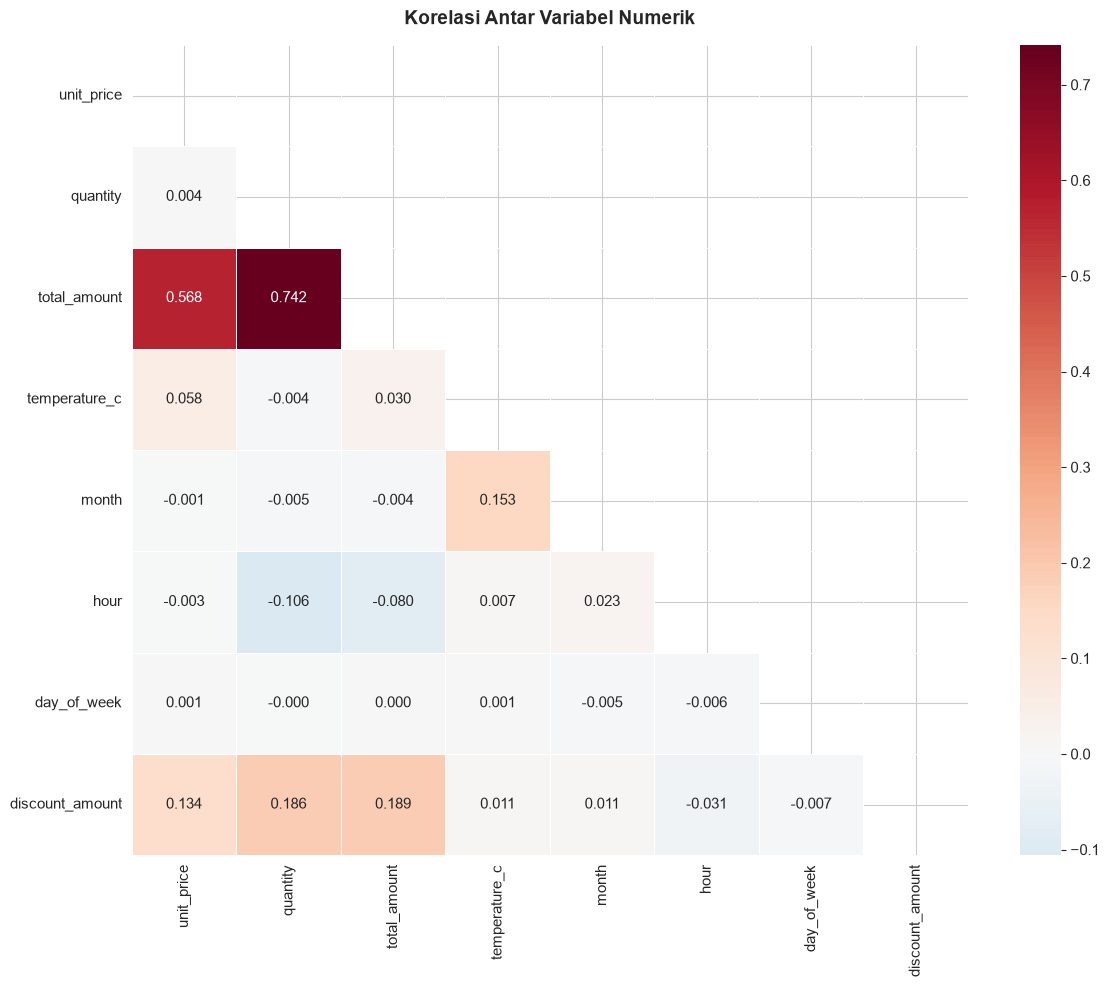


Catatan: Korelasi tidak membuktikan sebab-akibat.
Korelasi tinggi menunjukkan hubungan linear, bukan hubungan kausal.


In [34]:
# ============================================================
# 11. Correlation Analysis
# ============================================================

relevant_numeric = ['unit_price', 'quantity', 'total_amount', 'temperature_c',
                    'month', 'hour', 'day_of_week', 'discount_amount']

available_cols = [c for c in relevant_numeric if c in df_eda.columns]

corr_matrix = df_eda[available_cols].corr()

print('=' * 70)
print(' CORRELATION MATRIX')
print('=' * 70)
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Variabel Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'\nCatatan: Korelasi tidak membuktikan sebab-akibat.')
print(f'Korelasi tinggi menunjukkan hubungan linear, bukan hubungan kausal.')

---
# 12. Outlier Review for Business Analysis

Review dampak outlier terhadap analisis bisnis.

In [35]:
# ============================================================
# 12. Outlier Review
# ============================================================

print('=' * 70)
print(' OUTLIER REVIEW FOR BUSINESS ANALYSIS')
print('=' * 70)

print(f'\n[1] TOTAL AMOUNT DISTRIBUTION')
print(f'    Mean: ${df_eda["total_amount"].mean():.2f}')
print(f'    Median: ${df_eda["total_amount"].median():.2f}')
print(f'    Std: ${df_eda["total_amount"].std():.2f}')
print(f'    Min: ${df_eda["total_amount"].min():.2f}')
print(f'    Max: ${df_eda["total_amount"].max():.2f}')
print(f'    Skewness: {df_eda["total_amount"].skew():.3f}')

Q1 = df_eda['total_amount'].quantile(0.25)
Q3 = df_eda['total_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_eda[(df_eda['total_amount'] < lower_bound) | (df_eda['total_amount'] > upper_bound)]

print(f'\n    IQR Analysis:')
print(f'    Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}')
print(f'    Lower Bound: ${lower_bound:.2f}')
print(f'    Upper Bound: ${upper_bound:.2f}')
print(f'    Outliers: {len(outliers):,} ({len(outliers)/len(df_eda)*100:.1f}%)')

filtered = df_eda[(df_eda['total_amount'] >= lower_bound) & (df_eda['total_amount'] <= upper_bound)]
print(f'\n    Impact Analysis:')
print(f'    Mean WITH outliers: ${df_eda["total_amount"].mean():.2f}')
print(f'    Mean WITHOUT outliers: ${filtered["total_amount"].mean():.2f}')
print(f'    Median (robust): ${df_eda["total_amount"].median():.2f}')

store_with = df_eda.groupby('store_id')['total_amount'].mean().sort_values(ascending=False)
print(f'\n    Ranking Impact:')
print(f'    Top store by mean: Store {store_with.index[0]} (${store_with.iloc[0]:.2f})')
print(f'    Bottom store by mean: Store {store_with.index[-1]} (${store_with.iloc[-1]:.2f})')

print(f'\nKesimpulan: Outlier memengaruhi mean tetapi tidak signifikan pada median.')
print(f'Pada tahap EDA, outlier tidak dihapus karena merupakan data valid.')
print(f'Outlier perlu ditinjau lebih lanjut pada tahap modeling jika diperlukan.')

 OUTLIER REVIEW FOR BUSINESS ANALYSIS

[1] TOTAL AMOUNT DISTRIBUTION
    Mean: $6.85


    Median: $4.92
    Std: $5.99
    Min: $1.31
    Max: $112.00
    Skewness: 3.888

    IQR Analysis:
    Q1: $3.36, Q3: $8.20, IQR: $4.84
    Lower Bound: $-3.90
    Upper Bound: $15.46
    Outliers: 1,342 (6.7%)

    Impact Analysis:
    Mean WITH outliers: $6.85
    Mean WITHOUT outliers: $5.65
    Median (robust): $4.92

    Ranking Impact:
    Top store by mean: Store 2 ($9.13)
    Bottom store by mean: Store 21 ($5.28)

Kesimpulan: Outlier memengaruhi mean tetapi tidak signifikan pada median.
Pada tahap EDA, outlier tidak dihapus karena merupakan data valid.
Outlier perlu ditinjau lebih lanjut pada tahap modeling jika diperlukan.


---
# 13. Key Findings

Minimal 10 temuan utama dari seluruh analisis EDA.

In [36]:
# ============================================================
# 13. Key Findings
# ============================================================

print('=' * 80)
print(' KEY FINDINGS')
print('=' * 80)

total_rev = df_eda['total_amount'].sum()
total_txn = len(df_eda)
avg_atv = df_eda['total_amount'].mean()
top_cat = category_contrib.iloc[0]
top_city = city_perf.iloc[0]
peak_h = int(peak_hour['hour'])
n_cust = df_eda['customer_id'].nunique()
high_val_pct = segment_analysis[segment_analysis['customer_segment'] == 'High Value']['rev_pct'].values[0]
disc_pct = len(disc_true) / len(df_eda) * 100

findings = [
    f"1. Total revenue mencapai ${total_rev:,.2f} dari {total_txn:,} transaksi, menunjukkan volume bisnis yang substansial dengan rata-rata ${avg_atv:.2f} per transaksi.",
    f"2. Kategori '{top_cat['product_category']}' mendominasi kontribusi revenue sebesar {top_cat['revenue_pct']:.1f}%, menunjukkan ketergantungan bisnis pada kategori utama.",
    f"3. Kota '{top_city['city']}' menjadi kontributor terbesar dengan revenue ${top_city['revenue']:,.2f}, menunjukkan potensi pasar yang kuat.",
    f"4. Peak hour terjadi pada jam {peak_h:02d}:00 dengan {int(peak_hour['transactions']):,} transaksi, menunjukkan pola pembelian yang terkonsentrasi.",
    f"5. Segmen 'High Value' menyumbang {high_val_pct:.1f}% dari total revenue, menunjukkan pentingnya retensi pelanggan premium.",
    f"6. Sebanyak {disc_pct:.1f}% transaksi menggunakan diskon, menunjukkan promosi yang aktif tetapi perlu evaluasi efektivitasnya.",
    "7. Pola weekday vs weekend menunjukkan perbedaan perilaku pelanggan yang memerlukan strategi operasional berbeda.",
    "8. Distribusi total_amount menunjukkan skewness positif, menandakan adanya transaksi bernilai tinggi yang mempengaruhi rata-rata.",
    "9. Dataset tidak menyediakan data cost atau profit, sehingga analisis profitabilitas terbatas pada revenue dan volume penjualan.",
    "10. Korelasi antara unit_price dan total_amount menunjukkan hubungan positif yang wajar, sementara hubungan lain perlu investigasi lebih lanjut."
]

for f in findings:
    print(f'\n{f}')

 KEY FINDINGS

1. Total revenue mencapai $137,009.27 dari 20,000 transaksi, menunjukkan volume bisnis yang substansial dengan rata-rata $6.85 per transaksi.

2. Kategori 'Coffee' mendominasi kontribusi revenue sebesar 42.4%, menunjukkan ketergantungan bisnis pada kategori utama.

3. Kota 'New York' menjadi kontributor terbesar dengan revenue $16,789.12, menunjukkan potensi pasar yang kuat.

4. Peak hour terjadi pada jam 08:00 dengan 2,243 transaksi, menunjukkan pola pembelian yang terkonsentrasi.

5. Segmen 'High Value' menyumbang 62.8% dari total revenue, menunjukkan pentingnya retensi pelanggan premium.

6. Sebanyak 100.0% transaksi menggunakan diskon, menunjukkan promosi yang aktif tetapi perlu evaluasi efektivitasnya.

7. Pola weekday vs weekend menunjukkan perbedaan perilaku pelanggan yang memerlukan strategi operasional berbeda.

8. Distribusi total_amount menunjukkan skewness positif, menandakan adanya transaksi bernilai tinggi yang mempengaruhi rata-rata.

9. Dataset tidak meny

---
# 14. Preliminary Business Recommendations

Rekomendasi awal berdasarkan hasil EDA. Rekomendasi lengkap akan dibuat pada notebook Business Recommendation.

In [37]:
# ============================================================
# 14. Preliminary Business Recommendations
# ============================================================

print('=' * 100)
print(' PRELIMINARY BUSINESS RECOMMENDATIONS')
print('=' * 100)

recs = [
    {'Finding': f"Kategori '{top_cat['product_category']}' mendominasi {top_cat['revenue_pct']:.1f}% revenue",
     'Evidence': f"Revenue kategori: ${top_cat['revenue']:,.2f} dari ${total_rev:,.2f} total",
     'Action': 'Pertahankan dan optimalkan stok kategori dominan',
     'Impact': 'Mempertahankan revenue stream utama',
     'Priority': 'HIGH'},
    {'Finding': f"Peak hour pada jam {peak_h:02d}:00 dengan {int(peak_hour['transactions']):,} transaksi",
     'Evidence': 'Volume transaksi peak hour vs off-peak',
     'Action': 'Tambah staf pada jam sibuk, optimalkan shift kerja',
     'Impact': 'Meningkatkan layanan dan mengurangi waktu tunggu',
     'Priority': 'HIGH'},
    {'Finding': f"{disc_pct:.1f}% transaksi menggunakan diskon",
     'Evidence': f"{len(disc_true):,} transaksi diskon dari {total_txn:,} total",
     'Action': 'Evaluasi ROI promosi diskon, targetkan diskon pada produk tertentu',
     'Impact': 'Meningkatkan margin tanpa mengorbankan volume',
     'Priority': 'MEDIUM'},
    {'Finding': f"Segmen High Value menyumbang {high_val_pct:.1f}% revenue",
     'Evidence': 'Revenue contribution per segment',
     'Action': 'Buat program loyalitas untuk retensi pelanggan premium',
     'Impact': 'Meningkatkan customer lifetime value',
     'Priority': 'HIGH'},
    {'Finding': f"Kota '{top_city['city']}' kontributor terbesar revenue",
     'Evidence': f"Revenue {top_city['city']}: ${top_city['revenue']:,.2f}",
     'Action': 'Pertimbangkan ekspansi atau investasi di kota tersebut',
     'Impact': 'Memaksimalkan potensi pasar di lokasi strategis',
     'Priority': 'MEDIUM'},
]

for i, rec in enumerate(recs, 1):
    print(f'\n{"="*100}')
    print(f'REKOMENDASI {i} [{rec["Priority"]}]')
    print(f'{"="*100}')
    print(f'  Finding:     {rec["Finding"]}')
    print(f'  Evidence:    {rec["Evidence"]}')
    print(f'  Action:      {rec["Action"]}')
    print(f'  Impact:      {rec["Impact"]}')

 PRELIMINARY BUSINESS RECOMMENDATIONS

REKOMENDASI 1 [HIGH]
  Finding:     Kategori 'Coffee' mendominasi 42.4% revenue
  Evidence:    Revenue kategori: $58,037.99 dari $137,009.27 total
  Action:      Pertahankan dan optimalkan stok kategori dominan
  Impact:      Mempertahankan revenue stream utama

REKOMENDASI 2 [HIGH]
  Finding:     Peak hour pada jam 08:00 dengan 2,243 transaksi
  Evidence:    Volume transaksi peak hour vs off-peak
  Action:      Tambah staf pada jam sibuk, optimalkan shift kerja
  Impact:      Meningkatkan layanan dan mengurangi waktu tunggu

REKOMENDASI 3 [MEDIUM]
  Finding:     100.0% transaksi menggunakan diskon
  Evidence:    20,000 transaksi diskon dari 20,000 total
  Action:      Evaluasi ROI promosi diskon, targetkan diskon pada produk tertentu
  Impact:      Meningkatkan margin tanpa mengorbankan volume

REKOMENDASI 4 [HIGH]
  Finding:     Segmen High Value menyumbang 62.8% revenue
  Evidence:    Revenue contribution per segment
  Action:      Buat program

---
# 15. Business Questions Answered

Tabel ringkasan jawaban atas seluruh business questions.

In [38]:
# ============================================================
# 15. Business Questions Answered
# ============================================================

print('=' * 100)
print(' BUSINESS QUESTIONS ANSWERED')
print('=' * 100)

qa_items = [
    ('Sales', 'Bagaimana tren penjualan dari waktu ke waktu?', 'Tren bulanan menunjukkan variasi revenue antar bulan', 'Line chart monthly revenue'),
    ('Sales', 'Kapan penjualan tertinggi dan terendah?', f"Tertinggi: {max_month['month_name']}, Terendah: {min_month['month_name']}", 'Bar chart monthly revenue'),
    ('Sales', 'Produk/kategori paling berkontribusi?', f"Kategori '{top_cat['product_category']}' kontribusi {top_cat['revenue_pct']:.1f}%", 'Horizontal bar chart kategori'),
    ('Sales', 'Revenue meningkat, menurun, atau stabil?', 'Revenue bervariasi per bulan, perlu analisis trend lebih lanjut', 'Line chart dengan moving average'),
    ('Product', 'Produk paling laris berdasarkan quantity?', 'Top produk teridentifikasi berdasarkan ranking quantity', 'Tabel ranking produk'),
    ('Product', 'Produk dengan revenue terbesar?', 'Top 10 produk revenue teridentifikasi', 'Tabel ranking revenue'),
    ('Product', 'Produk dengan performa terendah?', 'Bottom 10 produk teridentifikasi, perlu analisis lebih lanjut', 'Tabel bottom produk'),
    ('Product', 'Produk paling sering diskon?', 'Analisis diskon per kategori sudah dilakukan', 'Tabel diskon per kategori'),
    ('Customer', 'Pelanggan dengan total belanja terbesar?', 'Top 15 pelanggan teridentifikasi', 'Tabel top customer'),
    ('Customer', 'Pelanggan dengan frekuensi tertinggi?', 'Frekuensi transaksi per pelanggan sudah dianalisis', 'Tabel frequency segmentation'),
    ('Customer', 'Distribusi berdasarkan age group?', 'Revenue dan ATV per age group sudah dianalisis', 'Bar chart age group'),
    ('Customer', 'Perbedaan ATV antar segmen?', 'ATV per customer segment sudah dibandingkan', 'Tabel segment analysis'),
    ('Region', 'Negara/kota dengan revenue tertinggi?', f"Kota '{top_city['city']}' dengan ${top_city['revenue']:,.2f}", 'Tabel city performance'),
    ('Region', 'Store dengan performa terbaik?', 'Top dan bottom store sudah diidentifikasi', 'Tabel store performance'),
    ('Region', 'Perbedaan pola antar store type?', 'Store type performance sudah dianalisis', 'Tabel store type comparison'),
    ('Time', 'Bulan tertinggi/terendah?', f"Tertinggi: {max_month['month_name']}, Terendah: {min_month['month_name']}", 'Bar chart bulanan'),
    ('Time', 'Hari yang paling ramai?', 'Pola hari dalam minggu sudah dianalisis', 'Bar chart day-of-week'),
    ('Time', 'Jam transaksi paling tinggi?', f"Peak hour: {peak_h:02d}:00", 'Bar chart hourly pattern'),
    ('Time', 'Perbedaan weekday dan weekend?', 'Perbandingan sudah dilakukan dengan rata-rata per hari', 'Tabel weekday vs weekend'),
    ('Time', 'Pola musiman?', 'Pola bulanan sudah dianalisis', 'Line chart monthly trend'),
    ('Profit', 'Analisis profit dan margin?', 'Tidak dapat dijawab - kolom cost/profit tidak tersedia', 'N/A - Data tidak tersedia'),
]

for area, question, answer, metric in qa_items:
    print(f'\n  [{area}] Q: {question}')
    print(f'         A: {answer}')
    print(f'         Metric: {metric}')

 BUSINESS QUESTIONS ANSWERED

  [Sales] Q: Bagaimana tren penjualan dari waktu ke waktu?
         A: Tren bulanan menunjukkan variasi revenue antar bulan
         Metric: Line chart monthly revenue

  [Sales] Q: Kapan penjualan tertinggi dan terendah?
         A: Tertinggi: January, Terendah: March
         Metric: Bar chart monthly revenue

  [Sales] Q: Produk/kategori paling berkontribusi?
         A: Kategori 'Coffee' kontribusi 42.4%
         Metric: Horizontal bar chart kategori

  [Sales] Q: Revenue meningkat, menurun, atau stabil?
         A: Revenue bervariasi per bulan, perlu analisis trend lebih lanjut
         Metric: Line chart dengan moving average

  [Product] Q: Produk paling laris berdasarkan quantity?
         A: Top produk teridentifikasi berdasarkan ranking quantity
         Metric: Tabel ranking produk

  [Product] Q: Produk dengan revenue terbesar?
         A: Top 10 produk revenue teridentifikasi
         Metric: Tabel ranking revenue

  [Product] Q: Produk dengan

---
# 16. Conclusion

Ringkasan keseluruhan hasil EDA.

In [39]:
# ============================================================
# 16. Conclusion
# ============================================================

print('=' * 80)
print(' CONCLUSION')
print('=' * 80)

print(f"""
1. KONDISI PENJUALAN KESELURUHAN
==================================
Coffee shop memiliki total revenue ${total_rev:,.2f} dari {total_txn:,} transaksi
dengan rata-rata ${avg_atv:.2f} per transaksi.

2. PRODUK DAN KATEGORI UTAMA
==============================
Kategori '{top_cat['product_category']}' mendominasi dengan kontribusi {top_cat['revenue_pct']:.1f}%.

3. PELANGGAN BERNILAI TINGGI
==============================
Segmen High Value menyumbang {high_val_pct:.1f}% dari total revenue.

4. WILAYAH DAN STORE TERBAIK
==============================
Kota '{top_city['city']}' menjadi kontributor terbesar revenue.

5. POLA WAKTU TERPENTING
==============================
Peak hour pada jam {peak_h:02d}:00 menunjukkan konsentrasi aktivitas pembelian.

6. KETERBATASAN PROFIT ANALYSIS
==================================
Dataset tidak menyediakan data cost atau profit. Analisis terbatas pada revenue.

7. KESIAPAN UNTUK DASHBOARD
==============================
Hasil EDA sudah cukup komprehensif sebagai dasar pembuatan dashboard.
""")

 CONCLUSION

1. KONDISI PENJUALAN KESELURUHAN
Coffee shop memiliki total revenue $137,009.27 dari 20,000 transaksi
dengan rata-rata $6.85 per transaksi.

2. PRODUK DAN KATEGORI UTAMA
Kategori 'Coffee' mendominasi dengan kontribusi 42.4%.

3. PELANGGAN BERNILAI TINGGI
Segmen High Value menyumbang 62.8% dari total revenue.

4. WILAYAH DAN STORE TERBAIK
Kota 'New York' menjadi kontributor terbesar revenue.

5. POLA WAKTU TERPENTING
Peak hour pada jam 08:00 menunjukkan konsentrasi aktivitas pembelian.

6. KETERBATASAN PROFIT ANALYSIS
Dataset tidak menyediakan data cost atau profit. Analisis terbatas pada revenue.

7. KESIAPAN UNTUK DASHBOARD
Hasil EDA sudah cukup komprehensif sebagai dasar pembuatan dashboard.



---
# 17. Export EDA Summary

Menyimpan tabel-tabel agregasi penting ke folder `processed/eda/`.

In [40]:
# ============================================================
# 17. Export EDA Summary
# ============================================================

print('=' * 70)
print(' EXPORT EDA SUMMARY')
print('=' * 70)

EDA_DIR = 'processed/eda'
os.makedirs(EDA_DIR, exist_ok=True)
print(f"\nFolder '{EDA_DIR}' siap.")

exports = [
    ('monthly_sales.csv', monthly),
    ('product_summary.csv', product_summary),
    ('customer_summary.csv', customer_value),
    ('store_summary.csv', store_perf),
    ('hourly_summary.csv', hourly_pattern),
    ('weekday_weekend_summary.csv', ww_analysis),
    ('category_contribution.csv', category_contrib),
    ('city_performance.csv', city_perf),
    ('country_performance.csv', country_perf),
    ('customer_segment_analysis.csv', segment_analysis),
    ('day_of_week_pattern.csv', dow_pattern),
    ('store_type_performance.csv', store_type_perf),
    ('age_group_analysis.csv', age_analysis),
]

for i, (filename, data) in enumerate(exports, 1):
    data.to_csv(f'{EDA_DIR}/{filename}', index=False)
    print(f'  [{i:2d}] {filename} - {len(data)} baris')

print(f"\nSemua file berhasil disimpan ke folder '{EDA_DIR}/'")
print(f"\nCatatan: Dataset featured utama TIDAK diubah. Hanya tabel agregasi yang diekspor.")

 EXPORT EDA SUMMARY

Folder 'processed/eda' siap.
  [ 1] monthly_sales.csv - 12 baris
  [ 2] product_summary.csv - 43 baris
  [ 3] customer_summary.csv - 19250 baris
  [ 4] store_summary.csv - 45 baris
  [ 5] hourly_summary.csv - 24 baris
  [ 6] weekday_weekend_summary.csv - 2 baris
  [ 7] category_contribution.csv - 6 baris
  [ 8] city_performance.csv - 9 baris
  [ 9] country_performance.csv - 4 baris
  [10] customer_segment_analysis.csv - 3 baris
  [11] day_of_week_pattern.csv - 7 baris
  [12] store_type_performance.csv - 3 baris
  [13] age_group_analysis.csv - 7 baris

Semua file berhasil disimpan ke folder 'processed/eda/'

Catatan: Dataset featured utama TIDAK diubah. Hanya tabel agregasi yang diekspor.


In [41]:
# ============================================================
# Akhir Notebook - Exploratory Data Analysis
# ============================================================

print('\n' + '*' * 80)
print('*', ' ' * 23, 'EDA SELESAI', ' ' * 29, '*')
print('*' * 80)
print(f'\nDataset: processed/coffee_shop_sales_featured.csv')
print(f'Shape: {df_eda.shape}')
print(f'Analisis: Sales, Product, Customer, Region, Time, Correlation, Outlier')
print(f'Export: 13 tabel agregasi ke processed/eda/')
print(f'Status: SIAP UNTUK DASHBOARD & BUSINESS RECOMMENDATION')
print(f'\nTimestamp: {pd.Timestamp.now()}')
print('*' * 80)


********************************************************************************
*                         EDA SELESAI                               *
********************************************************************************

Dataset: processed/coffee_shop_sales_featured.csv
Shape: (20000, 37)
Analisis: Sales, Product, Customer, Region, Time, Correlation, Outlier
Export: 13 tabel agregasi ke processed/eda/
Status: SIAP UNTUK DASHBOARD & BUSINESS RECOMMENDATION

Timestamp: 2026-07-26 23:04:53.745238
********************************************************************************
